In [11]:
import glob
import pickle
from collections import defaultdict
base = "/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/sed_fitting"

import os
from datetime import datetime
import numpy as np
from collections import OrderedDict
from tqdm.auto import tqdm
all_gs = glob.glob('/blue/adamginsburg/richardson.t/research/flux/r+24_models-1.2/s*')
all_gs = [g.split('/')[-1] for g in all_gs if 'ipynb' not in g]
# Cache pars tables for each geometry
pars_cache = {}
param_names = set()


def merge_geom_pickles(pattern):
    merged = {}
    files = sorted(glob.glob(pattern))
    print(f"Found {len(files)} files for pattern: {pattern}")
    
    for fn in files:
        #print last modfied date and time
        print(f"Processing file: {fn}, last modified date and time: {datetime.fromtimestamp(os.path.getmtime(fn))}")
        with open(fn, "rb") as f:
            d = pickle.load(f)

        for idx, entry in d.items():
            """
            if not isinstance(entry, dict):
                continue
            if 'model_id' not in entry or 'chi2' not in entry:
                continue
            if len(entry['model_id']) == 0 or len(entry['chi2']) == 0:
                continue
            """
            merged[idx] = entry
         

    return merged
combined_upper_dict = merge_geom_pickles(f"{base}/model_dict_upper_*.pkl")
combined_lower_dict = merge_geom_pickles(f"{base}/model_dict_lower_*.pkl")


with open(f"{base}/model_dict_upper_0.pkl", "rb") as f:
    d = pickle.load(f)
    print(len(d))
with open(f"{base}/model_dict_upper_1.pkl", "rb") as f:
    d = pickle.load(f)
    print(len(d))

all_idx_upper = [idx for idx, entry in combined_upper_dict.items()]
all_idx_lower = [idx for idx, entry in combined_lower_dict.items()]
all_upper_rows = [
    {'source_idx': src_idx, 'model_id': model_id, 'chi2': chi2}
    for src_idx, entry in combined_upper_dict.items()
    for model_id, chi2 in zip(entry['model_id'], entry['chi2'])
]

all_model_names_upper = [
    model_name
    for entry in combined_upper_dict.values()
    for model_name in entry['model_name']
]
all_model_ids_upper = [
    model_id
    for entry in combined_upper_dict.values()
    for model_id in entry['model_id']
]

all_chi2_upper = [
    chi2
    for entry in combined_upper_dict.values()
    for chi2 in entry['chi2']
]

all_stage_upper = [
    stage   
for entry in combined_upper_dict.values()
    for stage in entry['stage']
]

all_class_upper = [
    class_
    for entry in combined_upper_dict.values()
    for class_ in entry['class']
]

all_geo_upper = [
    geo
    for entry in combined_upper_dict.values()
    for geo in entry['geom']
]

all_lower_rows = [
    {'source_idx': src_idx, 'model_id': model_id, 'chi2': chi2}
    for src_idx, entry in combined_lower_dict.items()
    for model_id, chi2 in zip(entry['model_id'], entry['chi2'])
]
all_model_ids_lower = [
    model_id
    for entry in combined_lower_dict.values()
    for model_id in entry['model_id']
]
all_chi2_lower = [
    chi2
    for entry in combined_lower_dict.values()
    for chi2 in entry['chi2']
]

all_geo_lower = [
    geo
    for entry in combined_lower_dict.values()
    for geo in entry['geom']
]

all_stage_lower = [
    stage
    for entry in combined_lower_dict.values()
    for stage in entry['stage']
]
all_class_lower = [
    class_
    for entry in combined_lower_dict.values()
    for class_ in entry['class']    
]
all_model_names_lower = [
    model_name
    for entry in combined_lower_dict.values()
    for model_name in entry['model_name']
]
# Automatically collect all available parameters from each geometry's pars table



for g in tqdm(all_gs):
    geo = g.split('/')[-1]
    try:
        pars_tab = Table.read(f'/blue/adamginsburg/richardson.t/research/flux/pars/{geo}_augmented.fits')
        print(pars_tab.colnames)
        pars_cache[geo] = pars_tab
        # collect parameter names (skip MODEL_NAME)
        for col in pars_tab.colnames:
            if col == 'MODEL_NAME':
                continue
            param_names.add(col)
    except Exception as e:
        pars_cache[geo] = None

param_names = sorted(param_names)

# Build per-parameter arrays for upper and lower selections (aligned with all_geo_upper / all_geo_lower)
params_upper = OrderedDict([(p, []) for p in param_names])
params_lower = OrderedDict([(p, []) for p in param_names])

def _extract_value(pars, pname, idx):
    if pars is None or pname not in pars.colnames:
        return np.nan
    try:
        if pars[pname].ndim == 1:
            v = pars[pname][idx].item()
        elif pars[pname].ndim ==2:
            v = pars[pname][idx,3]
        # strip astropy Quantity
        if hasattr(v, 'value'):
            return float(v.value)
        return float(v)
    except Exception:
        return np.nan

for geo, model_name in zip(all_geo_upper, all_model_names_upper):
    pars = pars_cache.get(geo)
    if pars is None:
        for p in param_names:
            params_upper[p].append(np.nan)
        continue
    match_idx = np.where(pars['MODEL_NAME'] == model_name)[0]
    mi = match_idx[0] if match_idx.size>0 else None
    for p in param_names:
        if mi is None:
            params_upper[p].append(np.nan)
        else:
            params_upper[p].append(_extract_value(pars, p, mi))
for geo, model_name in zip(all_geo_lower, all_model_names_lower):
    pars = pars_cache.get(geo)
    if pars is None:
        for p in param_names:
            params_lower[p].append(np.nan)
        continue
    match_idx = np.where(pars['MODEL_NAME'] == model_name)[0]
    mi = match_idx[0] if match_idx.size>0 else None
    for p in param_names:
        if mi is None:
            params_lower[p].append(np.nan)
        else:
            params_lower[p].append(_extract_value(pars, p, mi))





Found 20 files for pattern: /orange/adamginsburg/w51/TaehwaYoo/jwst_w51/sed_fitting/model_dict_upper_*.pkl
Processing file: /orange/adamginsburg/w51/TaehwaYoo/jwst_w51/sed_fitting/model_dict_upper_0.pkl, last modified date and time: 2026-08-07 14:13:07
Processing file: /orange/adamginsburg/w51/TaehwaYoo/jwst_w51/sed_fitting/model_dict_upper_1.pkl, last modified date and time: 2026-08-07 14:07:33
Processing file: /orange/adamginsburg/w51/TaehwaYoo/jwst_w51/sed_fitting/model_dict_upper_10.pkl, last modified date and time: 2026-08-07 15:34:31
Processing file: /orange/adamginsburg/w51/TaehwaYoo/jwst_w51/sed_fitting/model_dict_upper_11.pkl, last modified date and time: 2026-08-07 16:45:32
Processing file: /orange/adamginsburg/w51/TaehwaYoo/jwst_w51/sed_fitting/model_dict_upper_12.pkl, last modified date and time: 2026-08-07 14:32:00
Processing file: /orange/adamginsburg/w51/TaehwaYoo/jwst_w51/sed_fitting/model_dict_upper_13.pkl, last modified date and time: 2026-08-07 14:30:03
Processing fi

  0%|          | 0/18 [00:00<?, ?it/s]

['MODEL_NAME', 'star.radius', 'star.temperature', 'envelope.rho_0', 'envelope.power', 'cavity.power', 'cavity.theta_0', 'cavity.rho_0', 'ambient.density', 'ambient.temperature', 'scattering', 'inclination', 'Model Luminosity', 'Line-of-Sight Masses', 'Sphere Masses', 'Outer Radius', 'Line-of-Sight Weighted Temperatures', 'Sphere Weighted Temperatures']
['MODEL_NAME', 'star.radius', 'star.temperature', 'envelope.rho_0', 'envelope.power', 'cavity.power', 'cavity.theta_0', 'cavity.rho_0', 'envelope.rmin', 'ambient.density', 'ambient.temperature', 'scattering', 'inclination', 'Model Luminosity', 'Line-of-Sight Masses', 'Sphere Masses', 'Outer Radius', 'Line-of-Sight Weighted Temperatures', 'Sphere Weighted Temperatures']
['MODEL_NAME', 'star.radius', 'star.temperature', 'disk.mass', 'disk.rmax', 'disk.beta', 'disk.p', 'disk.h100', 'envelope.rho_0', 'envelope.rc', 'ambient.density', 'ambient.temperature', 'scattering', 'inclination', 'Model Luminosity', 'Line-of-Sight Masses', 'Sphere Masse

/tmp/ipykernel_3579010/3657837011.py:168: UserWarning: Warning: converting a masked element to nan.
  return float(v)


In [12]:
combined_upper_dict = merge_geom_pickles(f"{base}/model_dict_upper_*.pkl")
combined_lower_dict = merge_geom_pickles(f"{base}/model_dict_lower_*.pkl")
def _iter(x):
    if x is None:
        return []
    if isinstance(x, (list, tuple, np.ndarray)):
        return x
    return [x]
all_class_lower = [int(s) for entry in combined_lower_dict.values() for s in _iter(entry.get('class'))]
all_class_upper = [int(s) for entry in combined_upper_dict.values() for s in _iter(entry.get('class'))]
all_stage_lower = [int(s) for entry in combined_lower_dict.values() for s in _iter(entry.get('stage'))]
all_stage_upper = [int(s) for entry in combined_upper_dict.values() for s in _iter(entry.get('stage'))]

params_upper['stage'] = all_stage_upper
params_lower['stage'] = all_stage_lower
params_upper['class'] = all_class_upper
params_lower['class'] = all_class_lower
print(all_stage_upper)
# Convert lists to numpy arrays for easy indexing
for p in param_names:
    params_upper[p] = np.asarray(params_upper[p], dtype=float)
    params_lower[p] = np.asarray(params_lower[p], dtype=float)
print(params_upper['stage'])

Found 20 files for pattern: /orange/adamginsburg/w51/TaehwaYoo/jwst_w51/sed_fitting/model_dict_upper_*.pkl
Processing file: /orange/adamginsburg/w51/TaehwaYoo/jwst_w51/sed_fitting/model_dict_upper_0.pkl, last modified date and time: 2026-08-07 14:13:07
Processing file: /orange/adamginsburg/w51/TaehwaYoo/jwst_w51/sed_fitting/model_dict_upper_1.pkl, last modified date and time: 2026-08-07 14:07:33
Processing file: /orange/adamginsburg/w51/TaehwaYoo/jwst_w51/sed_fitting/model_dict_upper_10.pkl, last modified date and time: 2026-08-07 15:34:31
Processing file: /orange/adamginsburg/w51/TaehwaYoo/jwst_w51/sed_fitting/model_dict_upper_11.pkl, last modified date and time: 2026-08-07 16:45:32
Processing file: /orange/adamginsburg/w51/TaehwaYoo/jwst_w51/sed_fitting/model_dict_upper_12.pkl, last modified date and time: 2026-08-07 14:32:00
Processing file: /orange/adamginsburg/w51/TaehwaYoo/jwst_w51/sed_fitting/model_dict_upper_13.pkl, last modified date and time: 2026-08-07 14:30:03
Processing fi

In [13]:
# Map commonly-used parameter names from the automated `params_upper`/`params_lower`
# into the legacy `*_upper` / `*_lower` arrays so downstream cells remain compatible.
import numpy as np
# determine expected lengths (may be zero if no params were found)
n_upper = len(next(iter(params_upper.values()))) if len(params_upper) > 0 else 0
n_lower = len(next(iter(params_lower.values()))) if len(params_lower) > 0 else 0

def _ensure(arr, n):
    try:
        a = np.asarray(arr, dtype=float)
        if a.size == n:
            return a
    except Exception:
        pass
    return np.full(n, np.nan)

# common parameter name mappings (fallback to NaN arrays if missing)
star_temperatures_upper = _ensure(params_upper.get('star.temperature'), n_upper)
star_temperatures_lower = _ensure(params_lower.get('star.temperature'), n_lower)
star_luminosities_upper = _ensure(params_upper.get('Model Luminosity'), n_upper)
star_luminosities_lower = _ensure(params_lower.get('Model Luminosity'), n_lower)
disk_masses_upper = _ensure(params_upper.get('disk.mass'), n_upper)
disk_masses_lower = _ensure(params_lower.get('disk.mass'), n_lower)
inclinations_upper = _ensure(params_upper.get('inclination'), n_upper)
inclinations_lower = _ensure(params_lower.get('inclination'), n_lower)
star_radius_upper = _ensure(params_upper.get('star.radius'), n_upper)
star_radius_lower = _ensure(params_lower.get('star.radius'), n_lower)
# array-like parameters may have been reduced to NaN during extraction; keep the slot
line_of_sight_masses_upper = _ensure(params_upper.get('Line-of-Sight Masses'), n_upper)
line_of_sight_masses_lower = _ensure(params_lower.get('Line-of-Sight Masses'), n_lower)
sphere_masses_upper = _ensure(params_upper.get('Sphere Masses'), n_upper)
sphere_masses_lower = _ensure(params_lower.get('Sphere Masses'), n_lower)
cavity_rho_0_upper = _ensure(params_upper.get('cavity.rho_0'), n_upper)
cavity_rho_0_lower = _ensure(params_lower.get('cavity.rho_0'), n_lower)
cavity_theta_0_upper = _ensure(params_upper.get('cavity.theta_0'), n_upper)
cavity_theta_0_lower = _ensure(params_lower.get('cavity.theta_0'), n_lower)



In [14]:
import os
os.environ["CRDS_PATH"] = os.path.expanduser("~/crds_cache")
os.makedirs(os.environ["CRDS_PATH"], exist_ok=True)

os.environ["CRDS_SERVER_URL"] = "https://jwst-crds.stsci.edu"
os.environ["CRDS_CONTEXT"] = "jwst_1460.pmap"

from astropy.table import Table
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
from astroquery.svo_fps import SvoFps
from astropy.wcs import WCS
from astropy.io import fits
from dust_extinction.averages import RL85_MWGC, CT06_MWLoc
from dust_extinction.parameter_averages import CCM89




def get_mag(catalog, ww, filtername='f140m' ):
    print(ww.proj_plane_pixel_area())
    
    flux= (catalog['flux_fit_' + filtername] * u.MJy/u.sr * ww.proj_plane_pixel_area()).to(u.Jy)
    eflux_jy = (catalog['flux_err_' + filtername] * u.MJy/u.sr *  ww.proj_plane_pixel_area()).to(u.Jy)

    jfilts = SvoFps.get_filter_list('JWST')
    jfilts.add_index('filterID')
    wav = int(filtername[1:-1])

    zeropoint_ab = 3631 * u.Jy  # Default to AB magnitude zero point
 
    if wav < 500:

        zeropoint_vega = u.Quantity(jfilts.loc[f'JWST/NIRCam.{filtername.upper()}']['ZeroPoint'], u.Jy)
    else:
        zeropoint_vega = u.Quantity(jfilts.loc[f'JWST/MIRI.{filtername.upper()}']['ZeroPoint'], u.Jy)
   
    abmag = -2.5 * np.log10(flux / zeropoint_ab) * u.mag
    abmag_err = 2.5 / np.log(10) * np.abs(eflux_jy / flux) * u.mag

    vegamag = -2.5 * np.log10(flux / zeropoint_vega) * u.mag
    vegamag_err = 2.5 / np.log(10) * np.abs(eflux_jy / flux) * u.mag

    return  vegamag, vegamag_err, abmag, abmag_err


image_filenames ={
    "f140m": "/orange/adamginsburg/jwst/w51/images/jw06151-o001_t001_nircam_clear-f140m-merged_i2d.fits",
    "f162m": "/orange/adamginsburg/jwst/w51/images/jw06151-o001_t001_nircam_clear-f162m-merged_i2d.fits",
    "f182m": "/orange/adamginsburg/jwst/w51/images/jw06151-o001_t001_nircam_clear-f182m-merged_i2d.fits",
    "f187n": "/orange/adamginsburg/jwst/w51/images/jw06151-o001_t001_nircam_clear-f187n-merged_i2d.fits",
    "f210m": "/orange/adamginsburg/jwst/w51/images/jw06151-o001_t001_nircam_clear-f210m-merged_i2d.fits",
    "f335m": "/orange/adamginsburg/jwst/w51/images/jw06151-o001_t001_nircam_clear-f335m-merged_i2d.fits",
    "f360m": "/orange/adamginsburg/jwst/w51/images/jw06151-o001_t001_nircam_clear-f360m-merged_i2d.fits",
    "f405n": "/orange/adamginsburg/jwst/w51/images/jw06151-o001_t001_nircam_clear-f405n-merged_i2d.fits",
    "f410m": "/orange/adamginsburg/jwst/w51/images/jw06151-o001_t001_nircam_clear-f410m-merged_i2d.fits", # weird, the filename is different from what is downloaded with the STScI pipeline...
    "f480m": "/orange/adamginsburg/jwst/w51/images/jw06151-o001_t001_nircam_clear-f480m-merged_i2d.fits",
    "f560w": "/orange/adamginsburg/jwst/w51/F560W/pipeline/jw06151-o002_t001_miri_f560w_i2d.fits",
    "f770w": "/orange/adamginsburg/jwst/w51/F770W/pipeline/jw06151-o002_t001_miri_f770w_i2d.fits",
    "f1000w": "/orange/adamginsburg/jwst/w51/F1000W/pipeline/jw06151-o002_t001_miri_f1000w_i2d.fits",
    "f1280w": "/orange/adamginsburg/jwst/w51/F1280W/pipeline/jw06151-o002_t001_miri_f1280w_i2d.fits",
    "f2100w": "/orange/adamginsburg/jwst/w51/F2100W/pipeline/jw06151-o002_t001_miri_f2100w_i2d.fits",
    
}
catalog = Table.read('/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/final_catalog_new_cfit_cut.fits')
nmatch = catalog['nmatch_bands']
catalog = catalog[nmatch>3]
print(catalog.colnames)


f140m_header = fits.getheader(image_filenames['f140m'], ext=('SCI', 1))
f162m_header = fits.getheader(image_filenames['f162m'], ext=('SCI', 1))
f182m_header = fits.getheader(image_filenames['f182m'], ext=('SCI', 1))
f210m_header = fits.getheader(image_filenames['f210m'], ext=('SCI', 1))
f335m_header = fits.getheader(image_filenames['f335m'], ext=('SCI', 1))
f360m_header = fits.getheader(image_filenames['f360m'], ext=('SCI', 1))
f405n_header = fits.getheader(image_filenames['f405n'], ext=('SCI', 1))
f410m_header = fits.getheader(image_filenames['f410m'], ext=('SCI', 1))
f480m_header = fits.getheader(image_filenames['f480m'], ext=('SCI', 1))
f560w_header = fits.getheader(image_filenames['f560w'], ext=('SCI', 1))
f770w_header = fits.getheader(image_filenames['f770w'], ext=('SCI', 1))
f1000w_header = fits.getheader(image_filenames['f1000w'], ext=('SCI', 1))
f1280w_header = fits.getheader(image_filenames['f1280w'], ext=('SCI', 1))
f2100w_header = fits.getheader(image_filenames['f2100w'], ext=('SCI', 1))



f140m_mag = get_mag(catalog, WCS(f140m_header), filtername='f140m')
f162m_mag = get_mag(catalog, WCS(f162m_header), filtername='f162m')
f182m_mag = get_mag(catalog, WCS(f182m_header), filtername='f182m')
f210m_mag = get_mag(catalog, WCS(f210m_header), filtername='f210m')
f335m_mag = get_mag(catalog, WCS(f335m_header), filtername='f335m')
f360m_mag = get_mag(catalog, WCS(f360m_header), filtername='f360m')
f405n_mag = get_mag(catalog, WCS(f405n_header), filtername='f405n')
f410m_mag = get_mag(catalog, WCS(f410m_header), filtername='f410m')
f480m_mag = get_mag(catalog, WCS(f480m_header), filtername='f480m')
f560w_mag = get_mag(catalog, WCS(f560w_header), filtername='f560w')
f770w_mag = get_mag(catalog, WCS(f770w_header), filtername='f770w')
f1000w_mag = get_mag(catalog, WCS(f1000w_header), filtername='f1000w')
f1280w_mag = get_mag(catalog, WCS(f1280w_header), filtername='f1280w')
f2100w_mag = get_mag(catalog, WCS(f2100w_header), filtername='f2100w')

f187n_header = fits.getheader(image_filenames['f187n'], ext=('SCI', 1))
f187n_mag = get_mag(catalog, WCS(f187n_header), filtername='f187n')


num_sources = len(catalog)

from dust_extinction.averages import RL85_MWGC, CT06_MWGC
from dust_extinction.parameter_averages import CCM89
import astropy.constants as const

ext = CT06_MWLoc()
def plot_extvec_cmd(ax, color1, mag1, ext=CT06_MWGC(), extvec_scale=200, start=None,
                    color='y', head_width=0.5, color1_data=None, mag1_data=None, label=None, fontsize=15):
    def get_wave(c):
        if c == '410m405': return 4.10*u.um
        if c == '405m410': return 4.05*u.um
        if c == 'Hmag': return 1.634*u.um
        if c == 'Ksmag': return 2.143527*u.um
        return int(c[1:-1])/100*u.um

    w1 = get_wave(color1[0])
    w2 = get_wave(color1[1])
    w3 = get_wave(mag1[0])

    if w1 > w2:
        w1, w2 = w2, w1
        color1 = color1[::-1]
    print(w1,w2,w3)

    # Only plot if all are in valid range
    try:
        e_1 = ext(1/w1) * extvec_scale
        e_2 = ext(1/w2) * extvec_scale
        e_3 = ext(1/w3) * extvec_scale
    except ValueError as e:
        print(f"Extinction vector not plotted: {e}")
        return
    print(w1,w2,w3)
    print(e_1, e_2, e_3)
    if start == None:
        mean_color1 = np.nanmean(color1_data)
        mean_mag1 = np.nanmean(mag1_data)
        std_color1 = np.nanstd(color1_data)
        std_mag1 = np.nanstd(mag1_data)
        if e_1 - e_2 < 0:
            std_color1 *= -1
        
    
        start2 = (mean_color1 + 2*std_color1, mean_mag1 + 2*std_mag1)
    else:
        start2 = start
    
    # Strip units for plotting if present
    if hasattr(start2[0], 'value'):
        start2_x = start2[0].value
        start2_y = start2[1].value
    else:
        start2_x = start2[0]
        start2_y = start2[1]

    ax.annotate(f'$A_V={extvec_scale}$', xy=(start2_x + (e_1 - e_2), start2_y + e_3),
                xytext=(start2_x, start2_y), fontsize=15,
                arrowprops=dict(arrowstyle='-|>', color=color,
                                shrinkA=0, shrinkB=0,
                                mutation_scale=20, linewidth=1.5))
    if label is not None:
        ax.plot([], [], color=color, marker='>', markersize=8,
                label=f'{label}', linestyle='-', linewidth=2)

    else:
        ax.plot([], [], color=color, marker='>', markersize=8,
                linestyle='-', linewidth=2)

imgsavedir = '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/plots/cmds/'
mags = {
    'f140m': f140m_mag,
    'f162m': f162m_mag,
    'f182m': f182m_mag,
    'f187n': f187n_mag,
    'f210m': f210m_mag,
    'f335m': f335m_mag,
    'f360m': f360m_mag,
    'f405n': f405n_mag,
    'f410m': f410m_mag,
    'f480m': f480m_mag,
    'f560w': f560w_mag,
    'f770w': f770w_mag,
    'f1000w': f1000w_mag,
    'f1280w': f1280w_mag,
    'f2100w': f2100w_mag,
}
filter_names = list(mags.keys())


import matplotlib as mpl
from matplotlib.path import Path
from astropy.table import Table
import crds
parsec_av0 = Table.read('/home/t.yoo/parsec_av0.txt', format='ascii')
parsec_av0.pprint(max_width=-1, max_lines=-1)   
m_init = parsec_av0['col4']  
parsec_av0 = parsec_av0[m_init<300]              
logage_av0 = parsec_av0['col3']
mass_av0 = parsec_av0['col6']
print(np.min(m_init), np.max(m_init))
print(np.min(mass_av0), np.max(mass_av0))
F140Mmag_av0 = parsec_av0['col39'] + 5*np.log10(5400)-5
F162Mmag_av0 = parsec_av0['col40']+ 5*np.log10(5400)-5
F182Mmag_av0 = parsec_av0['col41']+ 5*np.log10(5400)-5
F210Mmag_av0 = parsec_av0['col42']+ 5*np.log10(5400)-5
F335Mmag_av0 = parsec_av0['col45']+ 5*np.log10(5400)-5
F360Mmag_av0 = parsec_av0['col46']+ 5*np.log10(5400)-5
F410Mmag_av0 = parsec_av0['col47']+ 5*np.log10(5400)-5
F480Mmag_av0 = parsec_av0['col50']+ 5*np.log10(5400)-5
age_idx = logage_av0 == 6
idx_01msun = np.argmin(np.abs(mass_av0[age_idx]-0.1))
idx_20msun = np.argmin(np.abs(mass_av0[age_idx]-20))
print(F162Mmag_av0)
print('age_idx:', age_idx, 'idx_01msun:', idx_01msun, 'idx_20msun:', idx_20msun)
isochrone_x_start = F162Mmag_av0[age_idx][idx_01msun] - F210Mmag_av0[age_idx][idx_01msun]
isochrone_x_end = F162Mmag_av0[age_idx][idx_20msun] - F210Mmag_av0[age_idx][idx_20msun]
isocrhone_y_start = F162Mmag_av0[age_idx][idx_01msun]
isocrhone_y_end = F162Mmag_av0[age_idx][idx_20msun]
color_slope = (isocrhone_y_end - isocrhone_y_start) / (isochrone_x_end - isochrone_x_start)
color_intercept = isocrhone_y_start - color_slope * isochrone_x_start

def get_av(color, mag, ext=CT06_MWLoc(), color1=('f140m', 'f162m'), mag1=('f140m',), isochrone_line_params=None):
    # Get the slope and intercept of the isochrone line
    m_iso, b_iso = isochrone_line_params
    print('color1:', color1, 'mag1:', mag1)

    # Get the extinction vector components
    w_color1_1 = int(color1[0][1:-1])/100*u.um
    w_color1_2 = int(color1[1][1:-1])/100*u.um
    w_mag1 = int(mag1[0][1:-1])/100*u.um
    print('w_color1_1:', w_color1_1, 'w_color1_2:', w_color1_2, 'w_mag1:', w_mag1)

    e_color1_1 = ext(1/w_color1_1)
    e_color1_2 = ext(1/w_color1_2)
    e_mag1 = ext(1/w_mag1)

    # get the contact to the isochrone line along the extinction vector
    # the extinction vector can be represented as a line with slope m_ext = e_mag1 / (e_color1_1 - e_color1_2) and passing through the point (color, mag)
    m_ext = e_mag1 / (e_color1_1 - e_color1_2)
    b_ext = mag - m_ext * color

    # find the intersection of the isochrone line and the extinction vector
    x_int = (b_ext - b_iso) / (m_iso - m_ext)
    y_int = m_iso * x_int + b_iso

    # calculate A_V as the distance from (color, mag) to (x_int, y_int) along the extinction vector
    av = (mag - y_int) / ext(1/w_mag1)
    av[av < 0] = 0
    return av
parsec_mags = {
    'f140m': F140Mmag_av0,
    'f162m': F162Mmag_av0,
    'f182m': F182Mmag_av0,
    'f210m': F210Mmag_av0,
    'f335m': F335Mmag_av0,
    'f360m': F360Mmag_av0,
    'f410m': F410Mmag_av0,
    'f480m': F480Mmag_av0,
}

f162 = f162m_mag[0].to_value(u.mag)
f210 = f210m_mag[0].to_value(u.mag)
f360 = f360m_mag[0].to_value(u.mag)
f480 = f480m_mag[0].to_value(u.mag)
isochrone_x_start = parsec_mags['f162m'][age_idx][idx_01msun] - parsec_mags['f210m'][age_idx][idx_01msun]
isochrone_x_end = parsec_mags['f162m'][age_idx][idx_20msun] - parsec_mags['f210m'][age_idx][idx_20msun]
isochrone_y_start = parsec_mags['f162m'][age_idx][idx_01msun]
isochrone_y_end = parsec_mags['f162m'][age_idx][idx_20msun]

color_slope = (isochrone_y_end - isochrone_y_start) / (isochrone_x_end - isochrone_x_start)
color_intercept = isochrone_y_start - color_slope * isochrone_x_start
av_estimate = get_av(f162 - f210, f162, ext=CT06_MWLoc(), color1=('f162m', 'f210m'), mag1=('f162m',), isochrone_line_params=(color_slope, color_intercept))

line_slope = (27 - 7) / (1.3 - 0.4)
line_intercept = 7 - line_slope * 0.4


upper_idx = np.where((f360-f480 > 0.15 + (1.5/6)*(f162-f210)) & (f162 - (line_slope * (f162 - f210) + line_intercept) < 0))[0]
lower_idx = np.where((f360-f480 <= 0.15 + (1.5/6)*(f162-f210)) & (f162 - (line_slope * (f162 - f210) + line_intercept) < 0))[0]
print(len(catalog))
print(len(f360), len(f480), len(f162), len(f210))
print(len(upper_idx), len(lower_idx))

# get the index of the sources within the field of view of the ALMA images
W51b3 = '/orange/adamginsburg/w51/TaehwaYoo/2017.1.00293.S_W51_B3_LB/may2021_successful_imaging/'
alma_w51n_b3_filename = W51b3+'w51n.spw0thru19.14500.robust0.thr0.075mJy.mfs.I.startmod.selfcal7.image.tt0.pbcor.fits'
alma_w51e_b3_filename = W51b3+'w51e2.spw0thru19.14500.robust0.thr0.075mJy.mfs.I.startmod.selfcal7.image.tt0.pbcor.fits'

alma_w51n_b3 = fits.open(alma_w51n_b3_filename)
alma_w51e_b3 = fits.open(alma_w51e_b3_filename)

alma_w51n_b3_img = alma_w51n_b3[0].data[0,0,:,:]
alma_w51e_b3_img = alma_w51e_b3[0].data[0,0,:,:]

alma_w51n_b3_wcs = WCS(alma_w51n_b3[0].header, naxis=2)
alma_w51e_b3_wcs = WCS(alma_w51e_b3[0].header, naxis=2)


def check_in_fov(img, wcs, skycoord):
    pixcoord = wcs.world_to_pixel(skycoord)
    xpix = pixcoord[0]
    ypix = pixcoord[1]
    in_fov = (xpix >= 0) & (xpix < img.shape[1]) & (ypix >= 0) & (ypix < img.shape[0])
    #in_fov_and_isfinite = np.isfinite(img[ypix.astype(int)[in_fov], xpix.astype(int)[in_fov]])
    return np.where(in_fov)[0]
# or
inside_alma = np.union1d(check_in_fov(alma_w51n_b3_img, alma_w51n_b3_wcs, catalog['skycoord_ref']), check_in_fov(alma_w51e_b3_img, alma_w51e_b3_wcs, catalog['skycoord_ref']))

idx_inside_alma_upper = np.intersect1d(all_idx_upper, inside_alma)
idx_inside_alma_lower = np.intersect1d(all_idx_lower, inside_alma)

idx_outside_alma_upper = np.setdiff1d(all_idx_upper, inside_alma)
idx_outside_alma_lower = np.setdiff1d(all_idx_lower, inside_alma)

#index from all_idx_upper to idx_inside_alma_upper
idx_inside_alma_upper_in_all_idx_upper = np.where(np.isin(all_idx_upper, idx_inside_alma_upper))[0]
idx_inside_alma_lower_in_all_idx_lower = np.where(np.isin(all_idx_lower, idx_inside_alma_lower))[0]




['skycoord_ref', 'skycoord_ref_filtername', 'sep_f140m', 'id_f140m', 'skycoord_f140m', 'flux_fit_f140m', 'flux_err_f140m', 'mask_f140m', 'qfit_f140m', 'cfit_f140m', 'local_bkg_f140m', 'roundness1_f140m', 'roundness2_f140m', 'sharpness_f140m', 'from_sat_catalog_f140m', 'std_ra_f140m', 'std_dec_f140m', 'nmatch_f140m', 'nmatch_good_f140m', 'flux_err_prop_f140m', 'sep_f162m', 'id_f162m', 'skycoord_f162m', 'flux_fit_f162m', 'flux_err_f162m', 'mask_f162m', 'qfit_f162m', 'cfit_f162m', 'local_bkg_f162m', 'roundness1_f162m', 'roundness2_f162m', 'sharpness_f162m', 'from_sat_catalog_f162m', 'std_ra_f162m', 'std_dec_f162m', 'nmatch_f162m', 'nmatch_good_f162m', 'flux_err_prop_f162m', 'sep_f182m', 'id_f182m', 'skycoord_f182m', 'flux_fit_f182m', 'flux_err_f182m', 'mask_f182m', 'qfit_f182m', 'cfit_f182m', 'local_bkg_f182m', 'roundness1_f182m', 'roundness2_f182m', 'sharpness_f182m', 'from_sat_catalog_f182m', 'std_ra_f182m', 'std_dec_f182m', 'nmatch_f182m', 'nmatch_good_f182m', 'flux_err_prop_f182m', 's

Set DATE-AVG to '2025-05-06T16:59:22.406' from MJD-AVG.
Set DATE-END to '2025-05-06T17:21:22.408' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.271881 from OBSGEO-[XYZ].
Set OBSGEO-H to 1611441536.798 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2025-05-06T14:19:06.870' from MJD-AVG.
Set DATE-END to '2025-05-06T14:41:02.194' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.220336 from OBSGEO-[XYZ].
Set OBSGEO-H to 1610512569.543 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2025-05-06T15:11:59.611' from MJD-AVG.
Set DATE-END to '2025-05-06T15:35:36.878' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.237189 from OBSGEO-[XYZ].
Set OBSGEO-H to 1610816321.821 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2025-05-06T16:06:02.819' from MJD-AVG.
Set DATE-END to '2025-05-06T16:29:39.435' from MJD-END'. [astropy.wcs.wcs]


7.525093724479512e-11 deg2
7.52790883669383e-11 deg2
7.52510476872822e-11 deg2
7.52514718037244e-11 deg2


Set OBSGEO-B to   -25.254571 from OBSGEO-[XYZ].
Set OBSGEO-H to 1611129611.449 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2025-05-06T14:19:01.510' from MJD-AVG.
Set DATE-END to '2025-05-06T14:41:02.130' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.220310 from OBSGEO-[XYZ].
Set OBSGEO-H to 1610512065.053 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
/blue/adamginsburg/t.yoo/from_red/miniconda3/envs/py311/lib/python3.11/site-packages/astropy/units/quantity.py:653: RuntimeWarning: invalid value encountered in log10
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


3.053877779107583e-10 deg2
3.0536898714608487e-10 deg2


...

Set DATE-AVG to '2024-09-08T11:31:04.265' from MJD-AVG.
Set DATE-END to '2024-09-08T12:43:52.463' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to    -3.803760 from OBSGEO-[XYZ].
Set OBSGEO-H to 1291894033.527 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
/blue/adamginsburg/t.yoo/from_red/miniconda3/envs/py311/lib/python3.11/site-packages/astropy/units/quantity.py:653: RuntimeWarning: invalid value encountered in log10
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
Set DATE-AVG to '2024-09-08T11:39:49.277' from MJD-AVG.
Set DATE-END to '2024-09-08T12:52:42.510' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to    -3.797166 from OBSGEO-[XYZ].
Set OBSGEO-H to 1291845460.779 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2024-09-08T11:47:44.336' from MJD-AVG.
Set DATE-END to '2024-09-08T13:00:37.070' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to    -3.791203 from OBSGEO-[XYZ].
Set OBSGEO-H to 1291801554.144 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '

9.491652069110604e-10 deg2
9.491651972183757e-10 deg2


Set DATE-AVG to '2025-05-06T13:24:26.762' from MJD-AVG.
Set DATE-END to '2025-05-06T13:48:04.085' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.202551 from OBSGEO-[XYZ].
Set OBSGEO-H to 1610191901.140 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
/blue/adamginsburg/t.yoo/from_red/miniconda3/envs/py311/lib/python3.11/site-packages/astropy/units/quantity.py:653: RuntimeWarning: invalid value encountered in log10
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


7.524574264515582e-11 deg2
 col1    col2  col3      col4          col5       col6   col7   col8   col9  col10 col11 col12   col13  col14  col15  col16  col17  col18   col19   col20   col21   col22    col23     col24     col25   col26   col27   col28   col29   col30   col31   col32   col33   col34   col35   col36   col37   col38   col39   col40   col41   col42   col43   col44   col45   col46   col47   col48   col49   col50 
------ ------- ---- -------------- ------------ ------- ------ ------ ------ ----- ----- ------ ------- ------ ------ ------ ------ ----- --------- ----- --------- ------ --------- --------- --------- ------ ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- -------
0.0207 0.15867  5.0   0.0908484459 1.0897678296   0.091  -0.78 3.4382  2.881     0   0.0  0.545     0.0    0.0    0.0    0.0    0.0    -1 -2.54e-13   0.0    0.6936 0.2855  0

Set OBSGEO-B to   -23.022886 from OBSGEO-[XYZ].
Set OBSGEO-H to     5053.796 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


In [15]:
upper_mask = np.isin(all_idx_upper, idx_inside_alma_upper)
lower_mask = np.isin(all_idx_lower, idx_inside_alma_lower)

upper_idx = np.where(upper_mask)[0]
upper_temp_mask = (np.concatenate([np.arange(i*10, (i+1)*10) for i in upper_idx])
                   if upper_idx.size else np.array([], dtype=int))
lower_idx = np.where(lower_mask)[0]
lower_temp_mask = (np.concatenate([np.arange(i*10, (i+1)*10) for i in lower_idx])
                   if lower_idx.size else np.array([], dtype=int))

upper_outside_mask = np.isin(all_idx_upper, idx_outside_alma_upper)
lower_outside_mask = np.isin(all_idx_lower, idx_outside_alma_lower)

upper_outside_idx = np.where(upper_outside_mask)[0]
lower_outside_idx = np.where(lower_outside_mask)[0]
upper_temp_outside_mask = (np.concatenate([np.arange(i*10, (i+1)*10) for i in upper_outside_idx])
                   if upper_outside_idx.size else np.array([], dtype=int))
lower_temp_outside_mask = (np.concatenate([np.arange(i*10, (i+1)*10) for i in lower_outside_idx])
                   if lower_outside_idx.size else np.array([], dtype=int))

Disk Minimum Q
[125.22214002   0.29744366   1.2560441  ...   0.93122601   0.79622675
   4.81249675]
Plotting Disk Minimum Q: upper=5206, lower=4768
Line-of-Sight Masses
[0.00538861 0.43417295 0.03581044 ... 0.06059985        nan 0.02322779]
Plotting Line-of-Sight Masses: upper=4276, lower=3438
Line-of-Sight Weighted Temperatures
[20.20618056 31.53421904 18.22326355 ... 22.61370535         nan
 32.05274384]
Plotting Line-of-Sight Weighted Temperatures: upper=3814, lower=3082
Model Luminosity
[2.64871266 2.03683293 3.0951909  ... 7.71099586 0.25575023 1.64427698]
Plotting Model Luminosity: upper=5820, lower=5220
Outer Radius
[2.20174212e+05 1.51667746e+04 5.01360490e+03 ... 1.03561145e+04
 4.10045041e-02 1.18710188e+05]
Plotting Outer Radius: upper=5814, lower=5190
Sphere Masses
[0.00085298 0.43398304 0.0361579  ... 0.06352128        nan 0.0183391 ]
Plotting Sphere Masses: upper=3787, lower=3083
Sphere Weighted Temperatures
[37.04520021 31.53176937 18.34909576 ... 22.60745613         nan

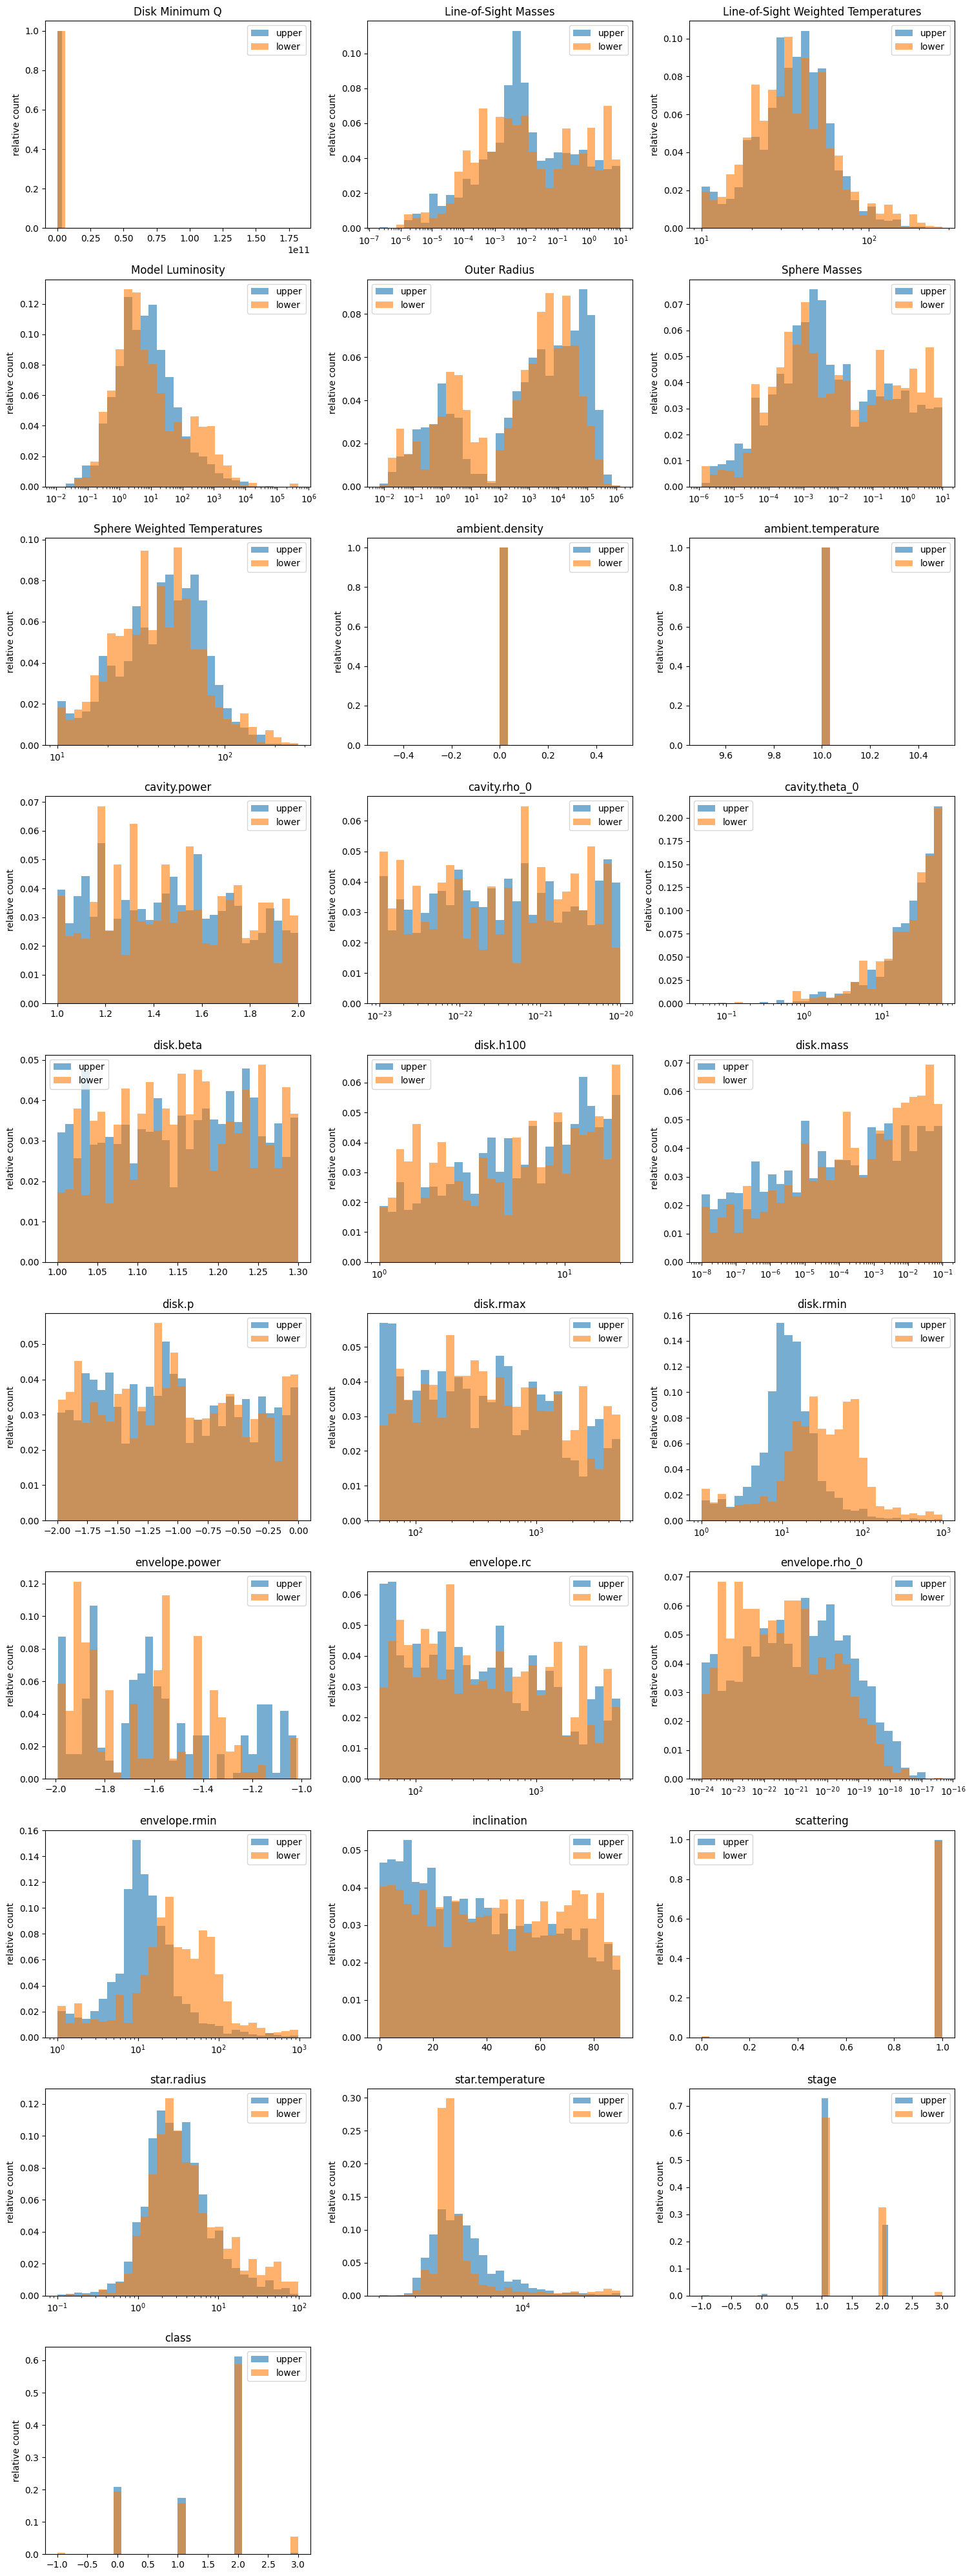

In [16]:
import matplotlib.pyplot as plt
import numpy as np

log_scales = ['disk.h100', 'Sphere Weighted Temperatures', 'Line-of-Sight Weighted Temperatures', 
'disk.rmax', 'envelope.rc', 'star.temperature']
# params_upper and params_lower (OrderedDict) should have been created in the previous cell
param_names = list(params_upper.keys())
if len(param_names) == 0:
    print('No parameters found in pars files')
else:
    nparams = len(param_names)
    ncols = 3
    nrows = int(np.ceil(nparams / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
    axes = np.array(axes).reshape(-1)

    def _select(arr, idx_arr):
        arr = np.atleast_1d(arr)
        idx_arr = np.asarray(idx_arr, dtype=int)
        if idx_arr.size == 0:
            return np.array([])
        idx_arr = idx_arr[idx_arr >= 0]
        idx_arr = idx_arr[idx_arr < arr.size]
        if idx_arr.size == 0:
            return np.array([])
        return arr[idx_arr]

    for i, p in enumerate(param_names):
        ax = axes[i]
        print(p)
        print(params_upper[p])
        a_up = _select(params_upper[p], upper_temp_mask)
        a_lo = _select(params_lower[p], lower_temp_mask)
        # drop NaNs
        a_up = a_up[~np.isnan(a_up)]
        a_lo = a_lo[~np.isnan(a_lo)]
        if a_up.size == 0 and a_lo.size == 0:
            ax.text(0.5, 0.5, f'no data for {p}', ha='center')
            ax.set_title(p)
            continue
        all_vals = np.concatenate([a_up, a_lo]) if (a_up.size + a_lo.size) > 0 else np.array([])
        amin = np.nanmin(all_vals)
        amax = np.nanmax(all_vals)
        # choose log bins for large dynamic range of positive values
        use_log = (amin > 0) and ((amax / amin) > 100)
        if p in log_scales:
            use_log = True
        if use_log:
            bins = np.logspace(np.log10(max(amin,1e-30)), np.log10(amax), 30)
            ax.set_xscale('log')
        else:
            bins = 30
        #print length of a_up and a_lo
        print(f'Plotting {p}: upper={a_up.size}, lower={a_lo.size}')
        if a_up.size>0:
            ax.hist(a_up, bins=bins, alpha=0.6, label='upper', color='C0', weights=np.ones_like(a_up)/a_up.size)
        if a_lo.size>0:
            ax.hist(a_lo, bins=bins, alpha=0.6, label='lower', color='C1', weights=np.ones_like(a_lo)/a_lo.size)
        ax.set_title(p)
        ax.set_ylabel('relative count')
        ax.legend()

    for j in range(nparams, axes.size):
        axes[j].axis('off')

    plt.tight_layout()



Disk Minimum Q
[125.22214002   0.29744366   1.2560441  ...   0.93122601   0.79622675
   4.81249675]
Plotting Disk Minimum Q: upper=4232, lower=3425
Line-of-Sight Masses
[0.00538861 0.43417295 0.03581044 ... 0.06059985        nan 0.02322779]
Plotting Line-of-Sight Masses: upper=4232, lower=3425
Line-of-Sight Weighted Temperatures
[20.20618056 31.53421904 18.22326355 ... 22.61370535         nan
 32.05274384]
Plotting Line-of-Sight Weighted Temperatures: upper=4232, lower=3425
Model Luminosity
[2.64871266 2.03683293 3.0951909  ... 7.71099586 0.25575023 1.64427698]
Plotting Model Luminosity: upper=4232, lower=3425
Outer Radius
[2.20174212e+05 1.51667746e+04 5.01360490e+03 ... 1.03561145e+04
 4.10045041e-02 1.18710188e+05]
Plotting Outer Radius: upper=4232, lower=3425
Sphere Masses
[0.00085298 0.43398304 0.0361579  ... 0.06352128        nan 0.0183391 ]
Plotting Sphere Masses: upper=4232, lower=3425
Sphere Weighted Temperatures
[37.04520021 31.53176937 18.34909576 ... 22.60745613         nan

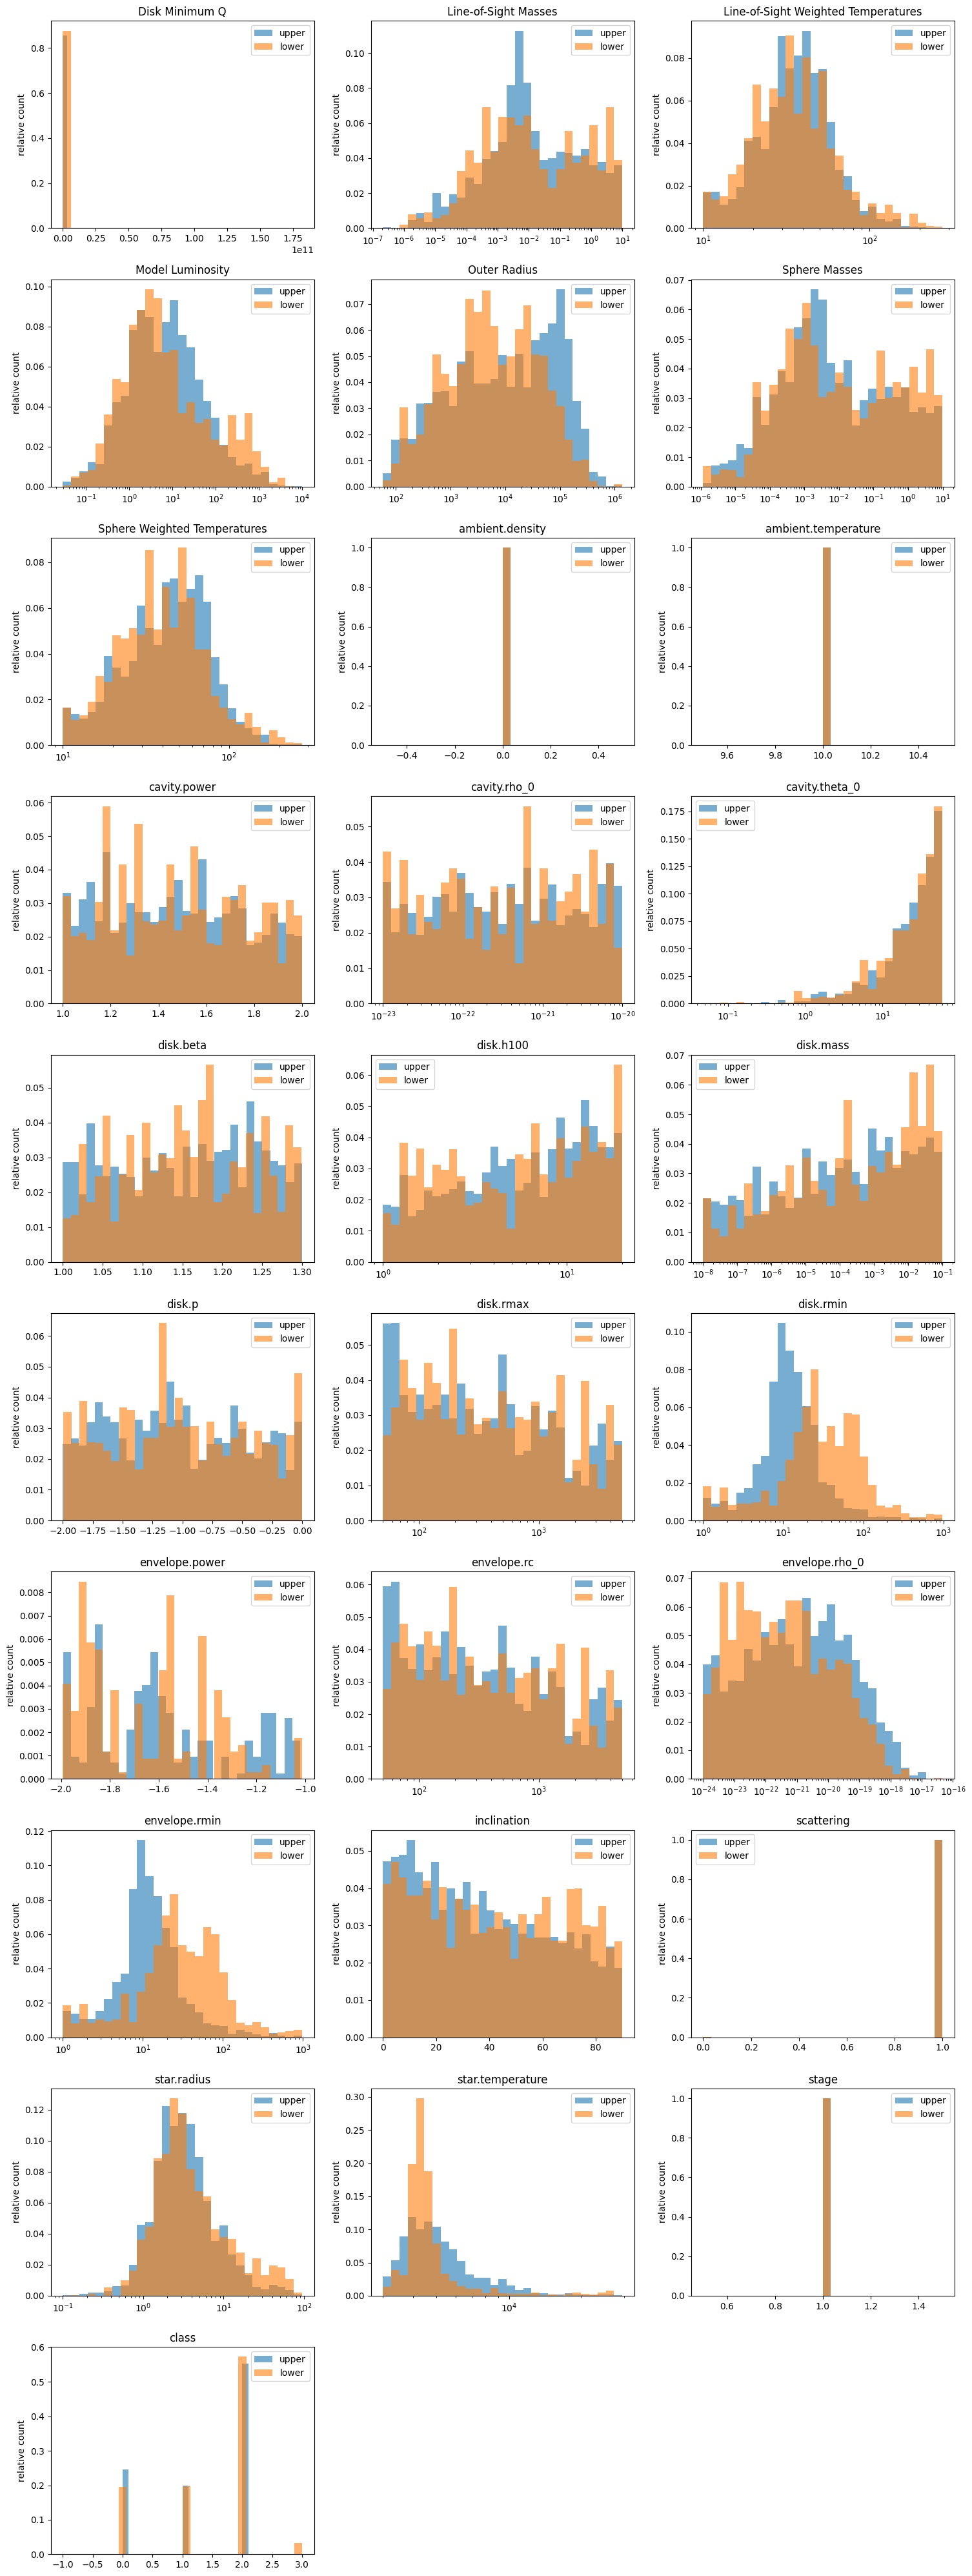

In [17]:
#get index of sources that are in the upper_temp_mask and stage==1
    

if len(param_names) == 0:
    print('No parameters found in pars files')
else:
    nparams = len(param_names)
    ncols = 3
    nrows = int(np.ceil(nparams / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
    axes = np.array(axes).reshape(-1)

    def _select(arr, idx_arr):
        arr = np.atleast_1d(arr)
        idx_arr = np.asarray(idx_arr, dtype=int)
        if idx_arr.size == 0:
            return np.array([])
        idx_arr = idx_arr[idx_arr >= 0]
        idx_arr = idx_arr[idx_arr < arr.size]
        if idx_arr.size == 0:
            return np.array([])
        return arr[idx_arr]

    for i, p in enumerate(param_names):
        ax = axes[i]
        print(p)
        print(params_upper[p])
        a_up = _select(params_upper[p], upper_temp_mask)
        a_lo = _select(params_lower[p], lower_temp_mask)
        # drop NaNs
        #a_up = a_up[~np.isnan(a_up)]
        #a_lo = a_lo[~np.isnan(a_lo)]
        stage_up = np.asarray(params_upper['stage'], dtype=int)
        stage_lo = np.asarray(params_lower['stage'], dtype=int)

        a_up = a_up[stage_up[upper_temp_mask] == 1]
        a_lo = a_lo[stage_lo[lower_temp_mask] == 1]
        if a_up.size == 0 and a_lo.size == 0:
            ax.text(0.5, 0.5, f'no data for {p}', ha='center')
            ax.set_title(p)
            continue
        all_vals = np.concatenate([a_up, a_lo]) if (a_up.size + a_lo.size) > 0 else np.array([])
        amin = np.nanmin(all_vals)
        amax = np.nanmax(all_vals)
        # choose log bins for large dynamic range of positive values
        use_log = (amin > 0) and ((amax / amin) > 100)
        if p in log_scales:
            use_log = True
        if use_log:
            bins = np.logspace(np.log10(max(amin,1e-30)), np.log10(amax), 30)
            ax.set_xscale('log')
        else:
            bins = 30
        #print length of a_up and a_lo
        print(f'Plotting {p}: upper={a_up.size}, lower={a_lo.size}')
        if a_up.size>0:
            ax.hist(a_up, bins=bins, alpha=0.6, label='upper', color='C0', weights=np.ones_like(a_up)/a_up.size)
        if a_lo.size>0:
            ax.hist(a_lo, bins=bins, alpha=0.6, label='lower', color='C1', weights=np.ones_like(a_lo)/a_lo.size)
        ax.set_title(p)
        ax.set_ylabel('relative count')
        ax.legend()

    for j in range(nparams, axes.size):
        axes[j].axis('off')

    plt.tight_layout()


model_lum_upper: [0.96731141 0.95129605 0.95129605 ... 1.57866219 1.61423042 1.57866219], disk_rmin_upper: [ 5.941  5.11   5.11  ... 17.21   5.77  17.21 ]


/tmp/ipykernel_3579010/3390991090.py:82: UserWarning: The following kwargs were not used by contour: 'lw'
  ax.contour(Xp, Yp, Z, levels=5, colors=color, alpha=0.7, lw=2)


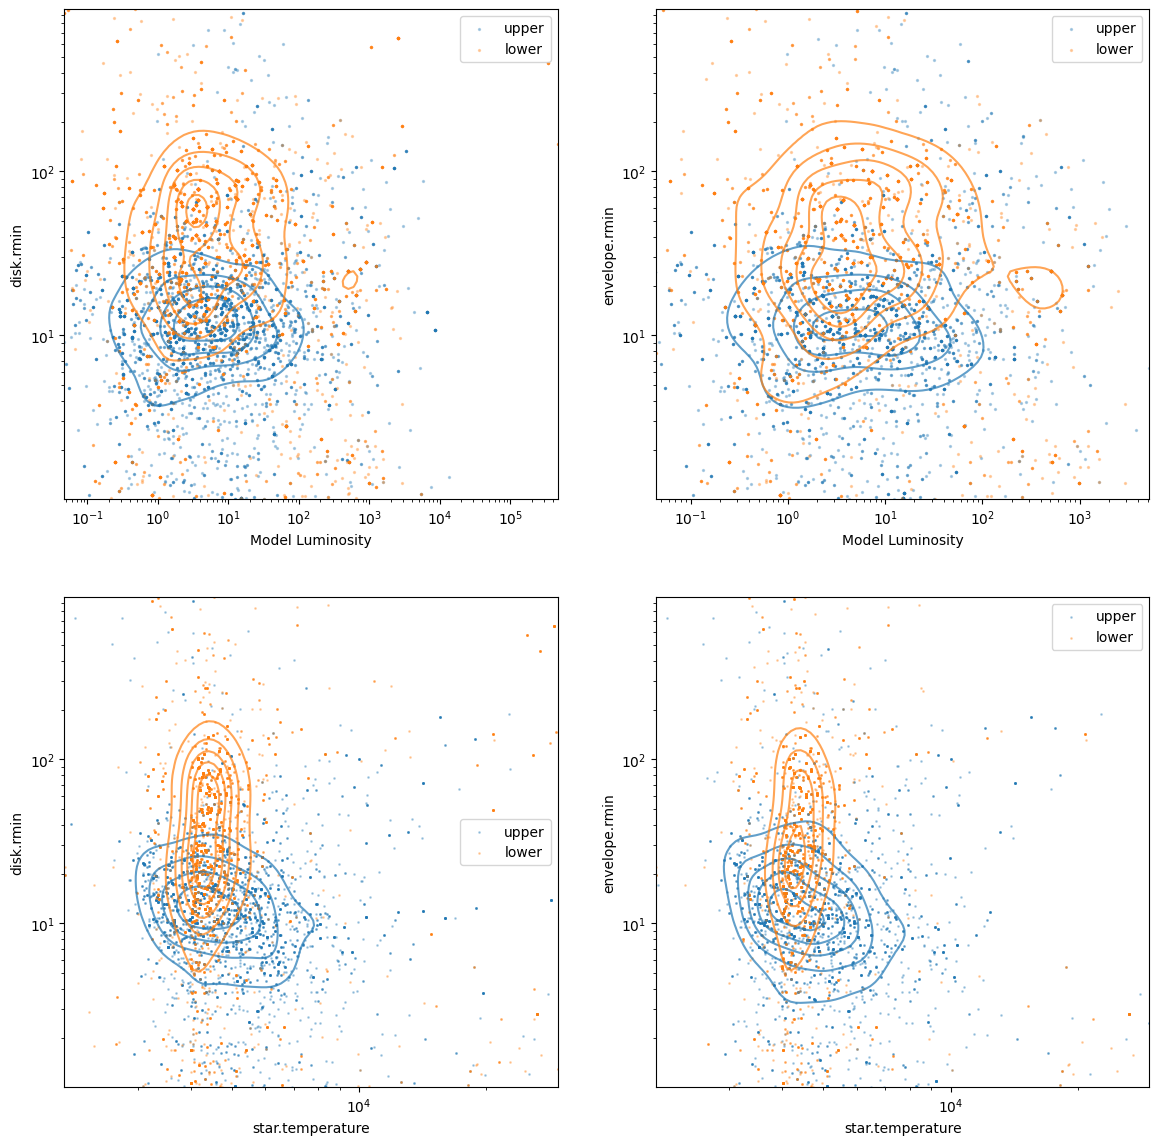

In [18]:
# scatter plot of model luminosity vs disk.rmin

model_lum_upper = _select(params_upper.get('Model Luminosity'), upper_temp_mask)
model_lum_lower = _select(params_lower.get('Model Luminosity'), lower_temp_mask)
stellar_temperature_upper = _select(params_upper.get('star.temperature'), upper_temp_mask)
stellar_temperature_lower = _select(params_lower.get('star.temperature'), lower_temp_mask)
disk_rmin_upper = _select(params_upper.get('disk.rmin'), upper_temp_mask)
disk_rmin_lower = _select(params_lower.get('disk.rmin'), lower_temp_mask)
envelope_rmin_upper = _select(params_upper.get('envelope.rmin'), upper_temp_mask)
envelope_rmin_lower = _select(params_lower.get('envelope.rmin'), lower_temp_mask)
print(f'model_lum_upper: {model_lum_upper}, disk_rmin_upper: {disk_rmin_upper}')
fig = plt.figure(figsize=(14,14))
ax1 = fig.add_subplot(221)
if model_lum_upper.size > 0 and disk_rmin_upper.size > 0:
    ax1.scatter(model_lum_upper, disk_rmin_upper, alpha=0.3, label='upper', color='C0', s=2)
if model_lum_lower.size > 0 and disk_rmin_lower.size > 0:   
    ax1.scatter(model_lum_lower, disk_rmin_lower, alpha=0.3, label='lower', color='C1', s=2)
ax1.set_xlabel('Model Luminosity')
ax1.set_ylabel('disk.rmin')
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.legend()
ax2 = fig.add_subplot(222)
if model_lum_upper.size > 0 and envelope_rmin_upper.size > 0:
    ax2.scatter(model_lum_upper, envelope_rmin_upper, alpha=0.3, label='upper', color='C0', s=2)
if model_lum_lower.size > 0 and envelope_rmin_lower.size > 0:
    ax2.scatter(model_lum_lower, envelope_rmin_lower, alpha=0.3, label='lower', color='C1', s=2)
ax2.set_xlabel('Model Luminosity')
ax2.set_ylabel('envelope.rmin')
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.legend()
ax3 = fig.add_subplot(223)
if stellar_temperature_upper.size > 0 and disk_rmin_upper.size > 0:
    ax3.scatter(stellar_temperature_upper, disk_rmin_upper, alpha=0.3, label='upper', color='C0', s=1)
if stellar_temperature_lower.size > 0 and disk_rmin_lower.size > 0:
    ax3.scatter(stellar_temperature_lower, disk_rmin_lower, alpha=0.3, label='lower', color='C1', s=1)
ax3.set_xlabel('star.temperature')
ax3.set_ylabel('disk.rmin')
ax3.set_xscale('log')
ax3.set_yscale('log')
ax3.legend()
ax4 = fig.add_subplot(224)
if stellar_temperature_upper.size > 0 and envelope_rmin_upper.size > 0:
    ax4.scatter(stellar_temperature_upper, envelope_rmin_upper, alpha=0.3, label='upper', color='C0', s=1)
if stellar_temperature_lower.size > 0 and envelope_rmin_lower.size > 0:
    ax4.scatter(stellar_temperature_lower, envelope_rmin_lower, alpha=0.3, label='lower', color='C1', s=1)
ax4.set_xlabel('star.temperature')
ax4.set_ylabel('envelope.rmin')
ax4.set_xscale('log')
ax4.set_yscale('log')
ax4.legend()

# draw density contours for upper and lower sources
# draw line with empty background to avoid overlapping with scatter points
from scipy.stats import gaussian_kde
def plot_density_contours(ax, x, y, color='C0', label=None, gridsize=100):
    x = np.asarray(x)
    y = np.asarray(y)

    finite = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
    x = x[finite]
    y = y[finite]

    if x.size < 5 or y.size < 5:
        return

    logx = np.log10(x)
    logy = np.log10(y)

    xy = np.vstack([logx, logy])
    kde = gaussian_kde(xy)

    xi = np.linspace(logx.min(), logx.max(), gridsize)
    yi = np.linspace(logy.min(), logy.max(), gridsize)
    X, Y = np.meshgrid(xi, yi)
    Z = kde(np.vstack([X.ravel(), Y.ravel()])).reshape(X.shape)

    Xp = 10 ** X
    Yp = 10 ** Y

    ax.contour(Xp, Yp, Z, levels=5, colors=color, alpha=0.7, lw=2)

    if label is not None:
        ax.plot([], [], color=color, label=label)
plot_density_contours(ax1, model_lum_upper, disk_rmin_upper, color='C0', label='upper')
plot_density_contours(ax1, model_lum_lower, disk_rmin_lower, color='C1', label='lower')
plot_density_contours(ax2, model_lum_upper, envelope_rmin_upper, color='C0', label='upper')
plot_density_contours(ax2, model_lum_lower, envelope_rmin_lower, color='C1', label='lower')
plot_density_contours(ax3, stellar_temperature_upper, disk_rmin_upper, color='C0', label='upper')
plot_density_contours(ax3, stellar_temperature_lower, disk_rmin_lower, color='C1', label='lower')
plot_density_contours(ax4, stellar_temperature_upper, envelope_rmin_upper, color='C0', label='upper')
plot_density_contours(ax4, stellar_temperature_lower, envelope_rmin_lower, color='C1', label='lower')


/tmp/ipykernel_3579010/3390991090.py:82: UserWarning: The following kwargs were not used by contour: 'lw'
  ax.contour(Xp, Yp, Z, levels=5, colors=color, alpha=0.7, lw=2)


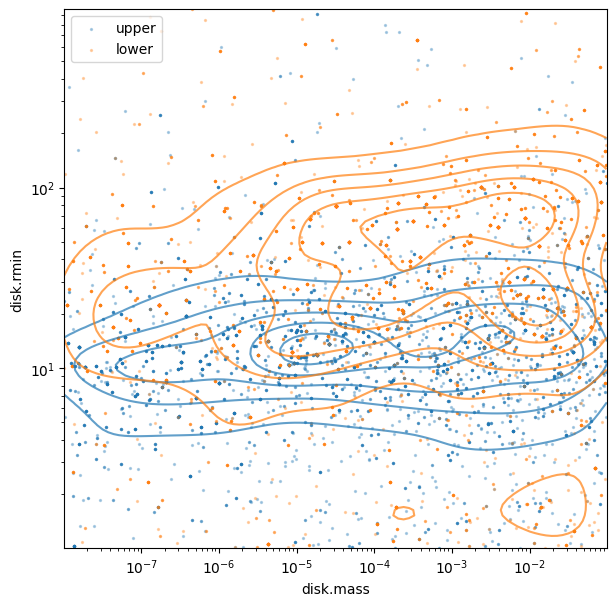

In [19]:
# scatter plot and contour plot of disk mass and disk.rmin
import matplotlib.pyplot as plt
disk_mass_upper = _select(params_upper.get('disk.mass'), upper_temp_mask)
disk_mass_lower = _select(params_lower.get('disk.mass'), lower_temp_mask)
fig = plt.figure(figsize=(7,7))
ax1= fig.add_subplot(111)
if disk_mass_upper.size > 0 and disk_rmin_upper.size > 0:
    ax1.scatter(disk_mass_upper, disk_rmin_upper, alpha=0.3, label='upper', color='C0', s=2)
if disk_mass_lower.size > 0 and disk_rmin_lower.size > 0:
    ax1.scatter(disk_mass_lower, disk_rmin_lower, alpha=0.3, label='lower', color='C1', s=2)
ax1.set_xlabel('disk.mass')
ax1.set_ylabel('disk.rmin')
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.legend()

if disk_mass_upper.size > 0 and disk_rmin_upper.size > 0:
    plot_density_contours(ax1, disk_mass_upper, disk_rmin_upper, color='C0', label='upper')
if disk_mass_lower.size > 0 and disk_rmin_lower.size > 0:
    plot_density_contours(ax1, disk_mass_lower, disk_rmin_lower, color='C1', label='lower')


[  30   31   32 ... 5810 5811 5812] [   0    1    2 ... 5817 5818 5819] [   0    1    2 ... 5817 5818 5819] [   0    1    2 ... 5817 5818 5819]


/tmp/ipykernel_3579010/3390991090.py:82: UserWarning: The following kwargs were not used by contour: 'lw'
  ax.contour(Xp, Yp, Z, levels=5, colors=color, alpha=0.7, lw=2)


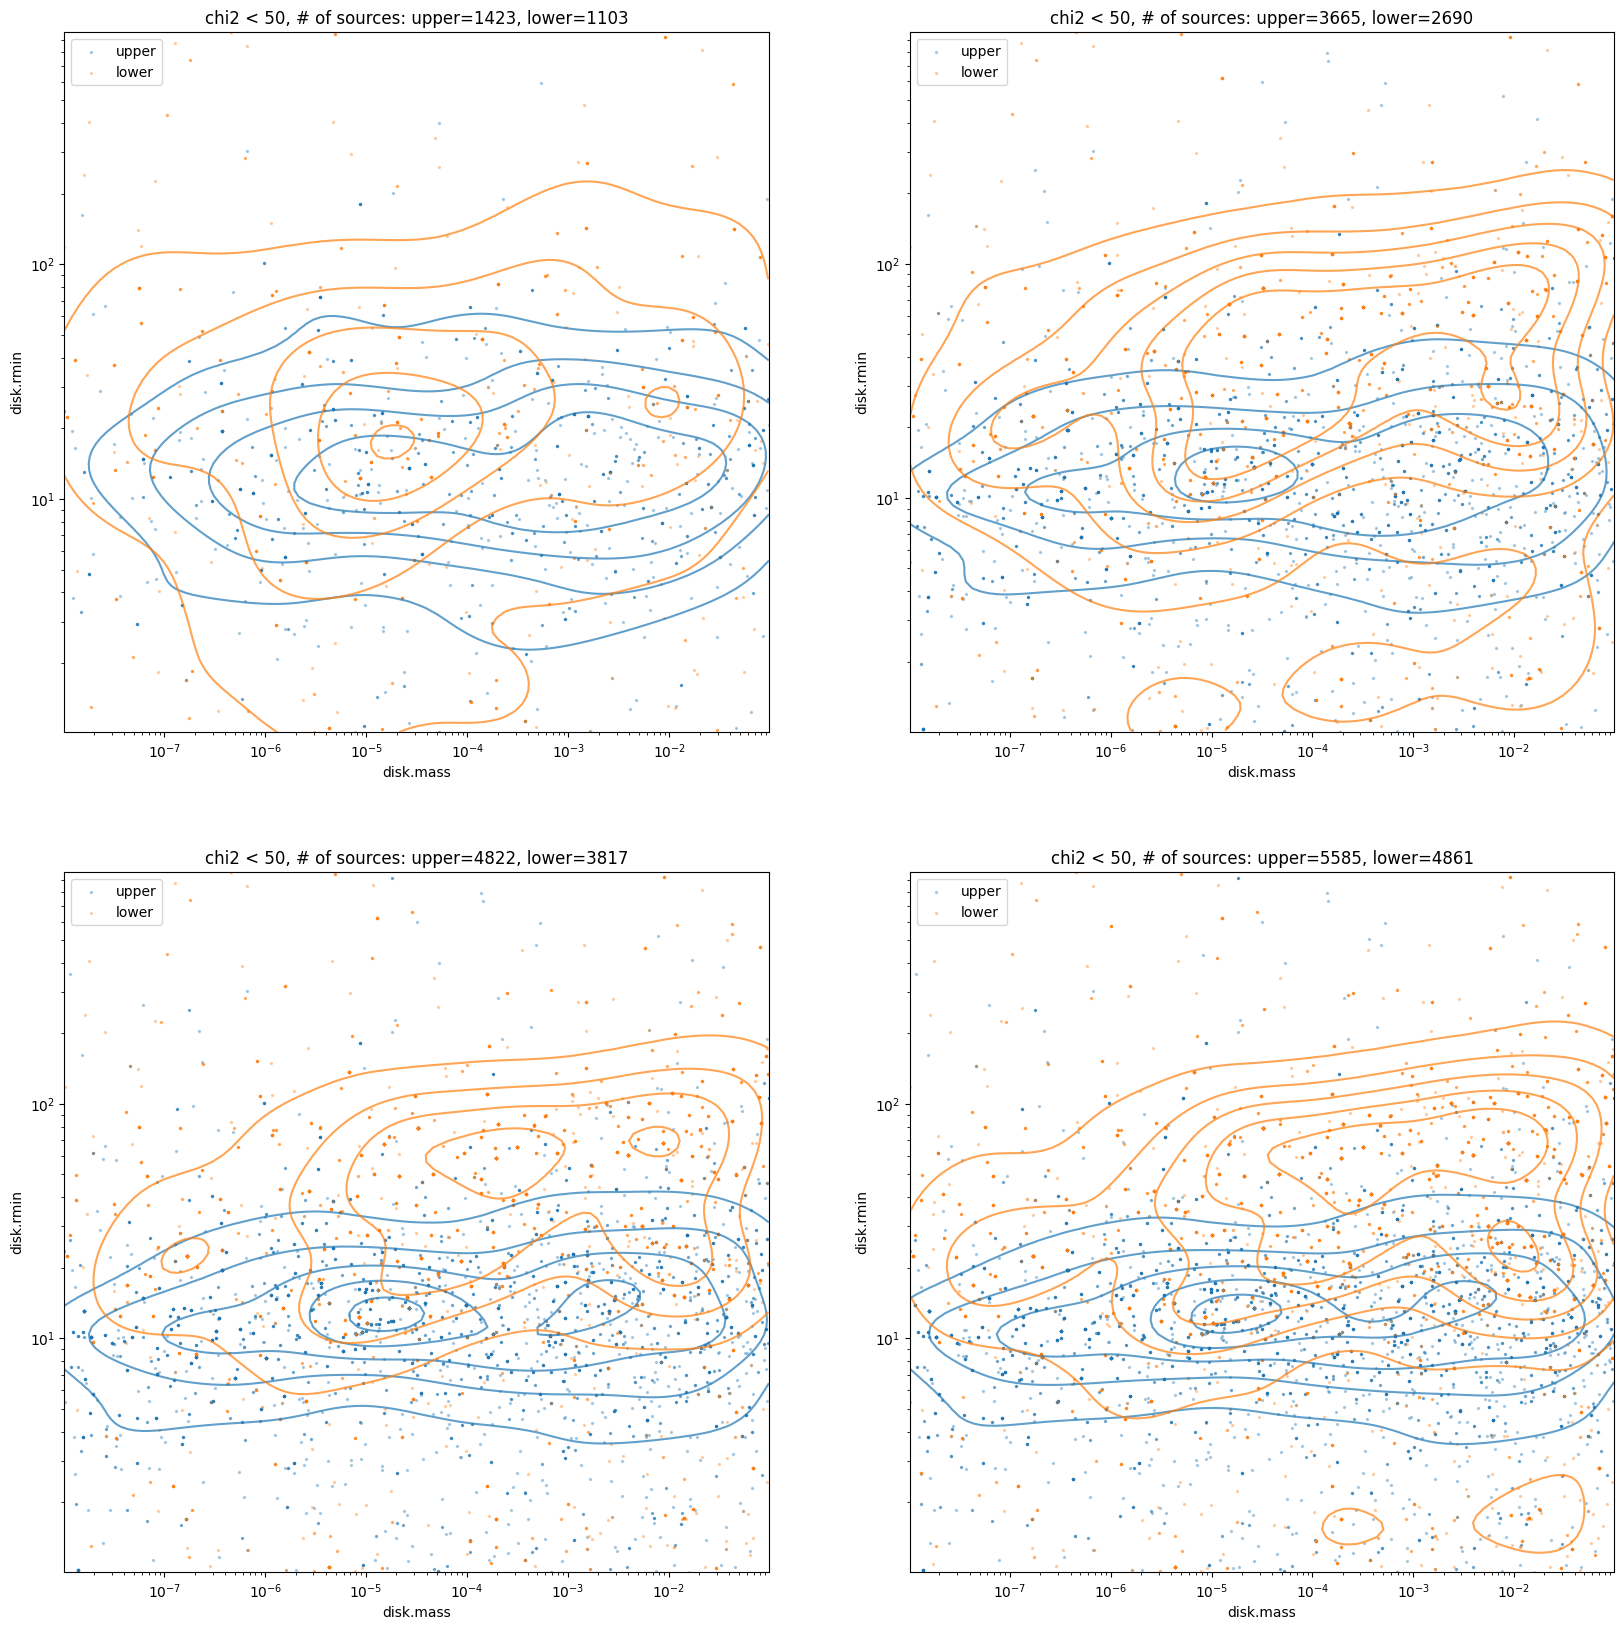

In [30]:
# scatter plot and contour plot of disk mass and disk.rmin with different chi2 values
chi2_upper_mask = _select(all_chi2_upper, upper_temp_mask)
chi2_lower_mask = _select(all_chi2_lower, lower_temp_mask)

chi2_ths = [50,200,500,2000]
chi2_idx1_upper = np.where((chi2_upper_mask <chi2_ths[0]) & (chi2_upper_mask > 0))[0]
chi2_idx2_upper = np.where((np.array(chi2_upper_mask) < chi2_ths[1]) & (np.array(chi2_upper_mask) > 0))[0]
chi2_idx3_upper = np.where((np.array(chi2_upper_mask) < chi2_ths[2]) & (np.array(chi2_upper_mask) > 0))[0]
chi2_idx4_upper = np.where((np.array(chi2_upper_mask) < chi2_ths[3]) & (np.array(chi2_upper_mask) > 0))[0]
print(chi2_idx1_upper, chi2_idx2_upper, chi2_idx3_upper, chi2_idx4_upper)
chi2_idx1_lower = np.where((np.array(chi2_lower_mask) < chi2_ths[0]) & (np.array(chi2_lower_mask) > 0))[0]
chi2_idx2_lower = np.where((np.array(chi2_lower_mask) < chi2_ths[1]) & (np.array(chi2_lower_mask) > 0))[0]
chi2_idx3_lower = np.where((np.array(chi2_lower_mask) < chi2_ths[2]) & (np.array(chi2_lower_mask) > 0))[0]
chi2_idx4_lower = np.where((np.array(chi2_lower_mask) < chi2_ths[3]) & (np.array(chi2_lower_mask) > 0))[0]

fig = plt.figure(figsize=(20,20))

axlist= [ax1, ax2, ax3, ax4] = [fig.add_subplot(221), fig.add_subplot(222), fig.add_subplot(223), fig.add_subplot(224)]
idxlist_upper = [chi2_idx1_upper, chi2_idx2_upper, chi2_idx3_upper, chi2_idx4_upper]
idxlist_lower = [chi2_idx1_lower, chi2_idx2_lower, chi2_idx3_lower, chi2_idx4_lower]
for idx_upper, idx_lower, ax in zip(idxlist_upper, idxlist_lower, axlist):
    if disk_mass_upper.size > 0 and disk_rmin_upper.size > 0:
        ax.scatter(disk_mass_upper[idx_upper], disk_rmin_upper[idx_upper], alpha=0.3, label='upper', color='C0', s=2)
    if disk_mass_lower.size > 0 and disk_rmin_lower.size > 0:
        ax.scatter(disk_mass_lower[idx_lower], disk_rmin_lower[idx_lower], alpha=0.3, label='lower', color='C1', s=2)
    ax.set_xlabel('disk.mass')
    ax.set_ylabel('disk.rmin')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.legend()
    plot_density_contours(ax, disk_mass_upper[idx_upper], disk_rmin_upper[idx_upper], color='C0', label='upper')
    plot_density_contours(ax, disk_mass_lower[idx_lower], disk_rmin_lower[idx_lower], color='C1', label='lower')
    ax.set_title(f'chi2 < {chi2_ths[0]}, # of sources: upper={len(idx_upper)}, lower={len(idx_lower)}')
    


In [20]:
ㅇㅇ

NameError: name 'ᄋᄋ' is not defined

Disk Minimum Q
[125.22214002   0.29744366   1.2560441  ...   0.93122601   0.79622675
   4.81249675]
Plotting Disk Minimum Q: upper=1525, lower=1706
Line-of-Sight Masses
[0.00538861 0.43417295 0.03581044 ... 0.06059985        nan 0.02322779]
Plotting Line-of-Sight Masses: upper=2, lower=5
Line-of-Sight Weighted Temperatures
[20.20618056 31.53421904 18.22326355 ... 22.61370535         nan
 32.05274384]
Plotting Line-of-Sight Weighted Temperatures: upper=2, lower=5
Model Luminosity
[2.64871266 2.03683293 3.0951909  ... 7.71099586 0.25575023 1.64427698]
Plotting Model Luminosity: upper=1525, lower=1706
Outer Radius
[2.20174212e+05 1.51667746e+04 5.01360490e+03 ... 1.03561145e+04
 4.10045041e-02 1.18710188e+05]
Plotting Outer Radius: upper=1525, lower=1706
Sphere Masses
[0.00085298 0.43398304 0.0361579  ... 0.06352128        nan 0.0183391 ]
Plotting Sphere Masses: upper=2, lower=5
Sphere Weighted Temperatures
[37.04520021 31.53176937 18.34909576 ... 22.60745613         nan
 34.76478734]
Plo

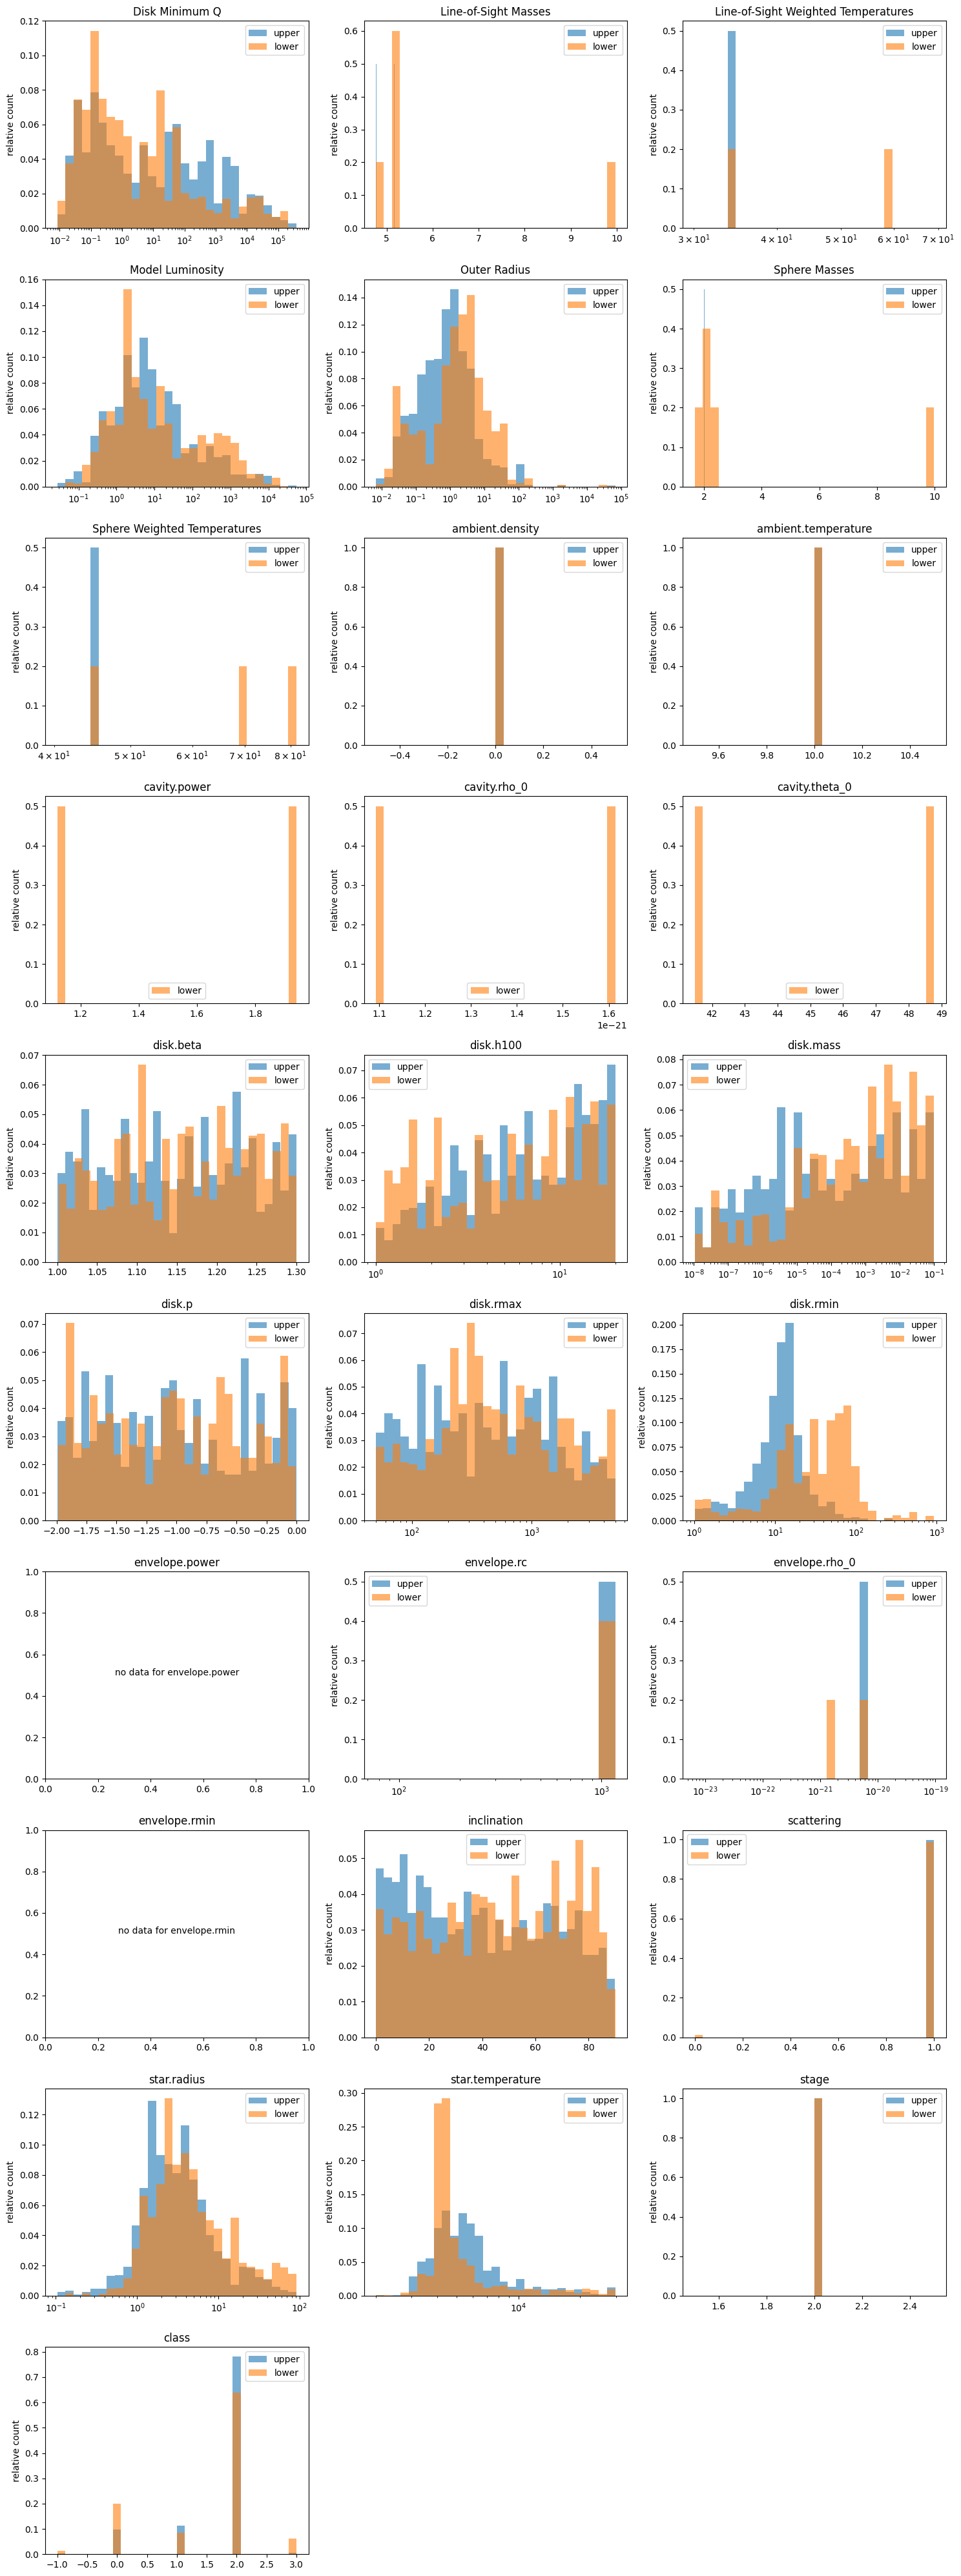

In [ ]:
#get index of sources that are in the upper_temp_mask and stage==1
    

if len(param_names) == 0:
    print('No parameters found in pars files')
else:
    nparams = len(param_names)
    ncols = 3
    nrows = int(np.ceil(nparams / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
    axes = np.array(axes).reshape(-1)

    def _select(arr, idx_arr):
        arr = np.atleast_1d(arr)
        idx_arr = np.asarray(idx_arr, dtype=int)
        if idx_arr.size == 0:
            return np.array([])
        idx_arr = idx_arr[idx_arr >= 0]
        idx_arr = idx_arr[idx_arr < arr.size]
        if idx_arr.size == 0:
            return np.array([])
        return arr[idx_arr]

    for i, p in enumerate(param_names):
        ax = axes[i]
        print(p)
        print(params_upper[p])
        a_up = _select(params_upper[p], upper_temp_mask)
        a_lo = _select(params_lower[p], lower_temp_mask)
        # drop NaNs
        #a_up = a_up[~np.isnan(a_up)]
        #a_lo = a_lo[~np.isnan(a_lo)]
        stage_up = np.asarray(params_upper['stage'], dtype=int)
        stage_lo = np.asarray(params_lower['stage'], dtype=int)

        a_up = a_up[stage_up[upper_temp_mask] == 2]
        a_lo = a_lo[stage_lo[lower_temp_mask] == 2]
        a_up = a_up[~np.isnan(a_up)]
        a_lo = a_lo[~np.isnan(a_lo)]
        if a_up.size == 0 and a_lo.size == 0:
            ax.text(0.5, 0.5, f'no data for {p}', ha='center')
            ax.set_title(p)
            continue
        all_vals = np.concatenate([a_up, a_lo]) if (a_up.size + a_lo.size) > 0 else np.array([])
        amin = np.nanmin(all_vals)
        amax = np.nanmax(all_vals)
        # choose log bins for large dynamic range of positive values
        use_log = (amin > 0) and ((amax / amin) > 100)
        if p in log_scales:
            use_log = True
        if use_log:
            bins = np.logspace(np.log10(max(amin,1e-30)), np.log10(amax), 30)
            ax.set_xscale('log')
        else:
            bins = 30
        #print length of a_up and a_lo
        print(f'Plotting {p}: upper={a_up.size}, lower={a_lo.size}')
        if a_up.size>0:
            ax.hist(a_up, bins=bins, alpha=0.6, label='upper', color='C0', weights=np.ones_like(a_up)/a_up.size)
        if a_lo.size>0:
            ax.hist(a_lo, bins=bins, alpha=0.6, label='lower', color='C1', weights=np.ones_like(a_lo)/a_lo.size)
        ax.set_title(p)
        ax.set_ylabel('relative count')
        ax.legend()

    for j in range(nparams, axes.size):
        axes[j].axis('off')

    plt.tight_layout()


Disk Minimum Q
[125.22214002   0.29744366   1.2560441  ...   0.93122601   0.79622675
   4.81249675]
Plotting Disk Minimum Q: upper=4497, lower=15996
Line-of-Sight Masses
[0.00538861 0.43417295 0.03581044 ... 0.06059985        nan 0.02322779]
Plotting Line-of-Sight Masses: upper=3657, lower=11692
Line-of-Sight Weighted Temperatures
[20.20618056 31.53421904 18.22326355 ... 22.61370535         nan
 32.05274384]
Plotting Line-of-Sight Weighted Temperatures: upper=3203, lower=9857
Model Luminosity
[2.64871266 2.03683293 3.0951909  ... 7.71099586 0.25575023 1.64427698]
Plotting Model Luminosity: upper=5040, lower=17060
Outer Radius
[2.20174212e+05 1.51667746e+04 5.01360490e+03 ... 1.03561145e+04
 4.10045041e-02 1.18710188e+05]
Plotting Outer Radius: upper=5025, lower=17026
Sphere Masses
[0.00085298 0.43398304 0.0361579  ... 0.06352128        nan 0.0183391 ]
Plotting Sphere Masses: upper=3177, lower=9868
Sphere Weighted Temperatures
[37.04520021 31.53176937 18.34909576 ... 22.60745613        

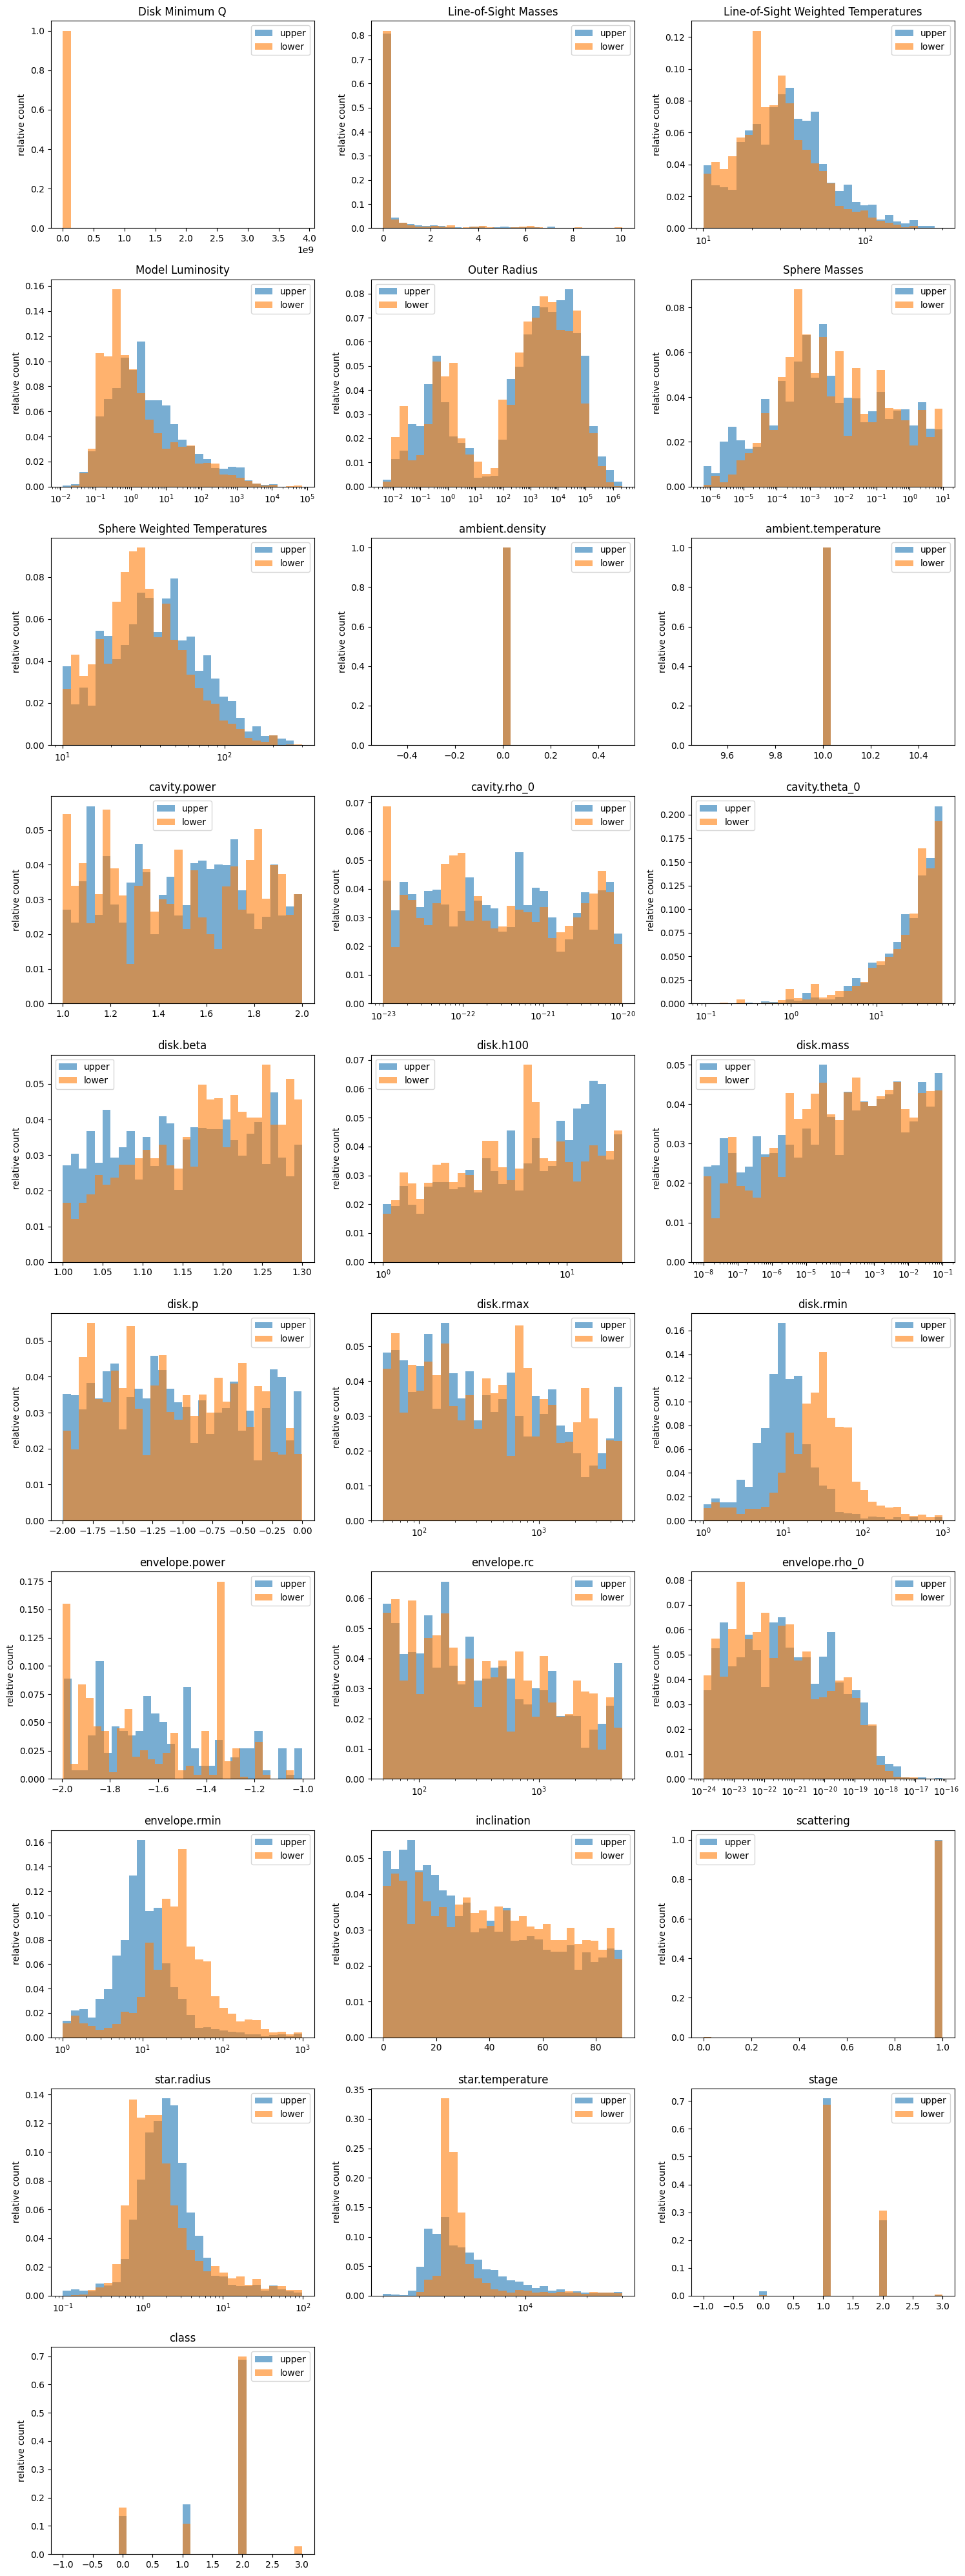

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

log_scales = ['disk.h100', 'Sphere Weighted Temperatures', 'Line-of-Sight Weighted Temperatures', 
'disk.rmax', 'envelope.rc', 'star.temperature']
# params_upper and params_lower (OrderedDict) should have been created in the previous cell
param_names = list(params_upper.keys())
if len(param_names) == 0:
    print('No parameters found in pars files')
else:
    nparams = len(param_names)
    ncols = 3
    nrows = int(np.ceil(nparams / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
    axes = np.array(axes).reshape(-1)

    def _select(arr, idx_arr):
        arr = np.atleast_1d(arr)
        idx_arr = np.asarray(idx_arr, dtype=int)
        if idx_arr.size == 0:
            return np.array([])
        idx_arr = idx_arr[idx_arr >= 0]
        idx_arr = idx_arr[idx_arr < arr.size]
        if idx_arr.size == 0:
            return np.array([])
        return arr[idx_arr]

    for i, p in enumerate(param_names):
        ax = axes[i]
        print(p)
        print(params_upper[p])
        a_up = _select(params_upper[p], upper_temp_outside_mask)
        a_lo = _select(params_lower[p], lower_temp_outside_mask)
        # drop NaNs
        a_up = a_up[~np.isnan(a_up)]
        a_lo = a_lo[~np.isnan(a_lo)]
        if a_up.size == 0 and a_lo.size == 0:
            ax.text(0.5, 0.5, f'no data for {p}', ha='center')
            ax.set_title(p)
            continue
        all_vals = np.concatenate([a_up, a_lo]) if (a_up.size + a_lo.size) > 0 else np.array([])
        amin = np.nanmin(all_vals)
        amax = np.nanmax(all_vals)
        # choose log bins for large dynamic range of positive values
        use_log = (amin > 0) and ((amax / amin) > 100)
        if p in log_scales:
            use_log = True
        if use_log:
            bins = np.logspace(np.log10(max(amin,1e-30)), np.log10(amax), 30)
            ax.set_xscale('log')
        else:
            bins = 30
        #print length of a_up and a_lo
        print(f'Plotting {p}: upper={a_up.size}, lower={a_lo.size}')
        if a_up.size>0:
            ax.hist(a_up, bins=bins, alpha=0.6, label='upper', color='C0', weights=np.ones_like(a_up)/a_up.size)
        if a_lo.size>0:
            ax.hist(a_lo, bins=bins, alpha=0.6, label='lower', color='C1', weights=np.ones_like(a_lo)/a_lo.size)
        ax.set_title(p)
        ax.set_ylabel('relative count')
        ax.legend()

    for j in range(nparams, axes.size):
        axes[j].axis('off')

    plt.tight_layout()



Disk Minimum Q
[125.22214002   0.29744366   1.2560441  ...   0.93122601   0.79622675
   4.81249675]
Plotting Disk Minimum Q: upper=10860, lower=22280
Line-of-Sight Masses
[0.00538861 0.43417295 0.03581044 ... 0.06059985        nan 0.02322779]
Plotting Line-of-Sight Masses: upper=10860, lower=22280
Line-of-Sight Weighted Temperatures
[20.20618056 31.53421904 18.22326355 ... 22.61370535         nan
 32.05274384]
Plotting Line-of-Sight Weighted Temperatures: upper=10860, lower=22280
Model Luminosity
[2.64871266 2.03683293 3.0951909  ... 7.71099586 0.25575023 1.64427698]
Plotting Model Luminosity: upper=10860, lower=22280
Outer Radius
[2.20174212e+05 1.51667746e+04 5.01360490e+03 ... 1.03561145e+04
 4.10045041e-02 1.18710188e+05]
Plotting Outer Radius: upper=10860, lower=22280
Sphere Masses
[0.00085298 0.43398304 0.0361579  ... 0.06352128        nan 0.0183391 ]
Plotting Sphere Masses: upper=10860, lower=22280
Sphere Weighted Temperatures
[37.04520021 31.53176937 18.34909576 ... 22.60745613

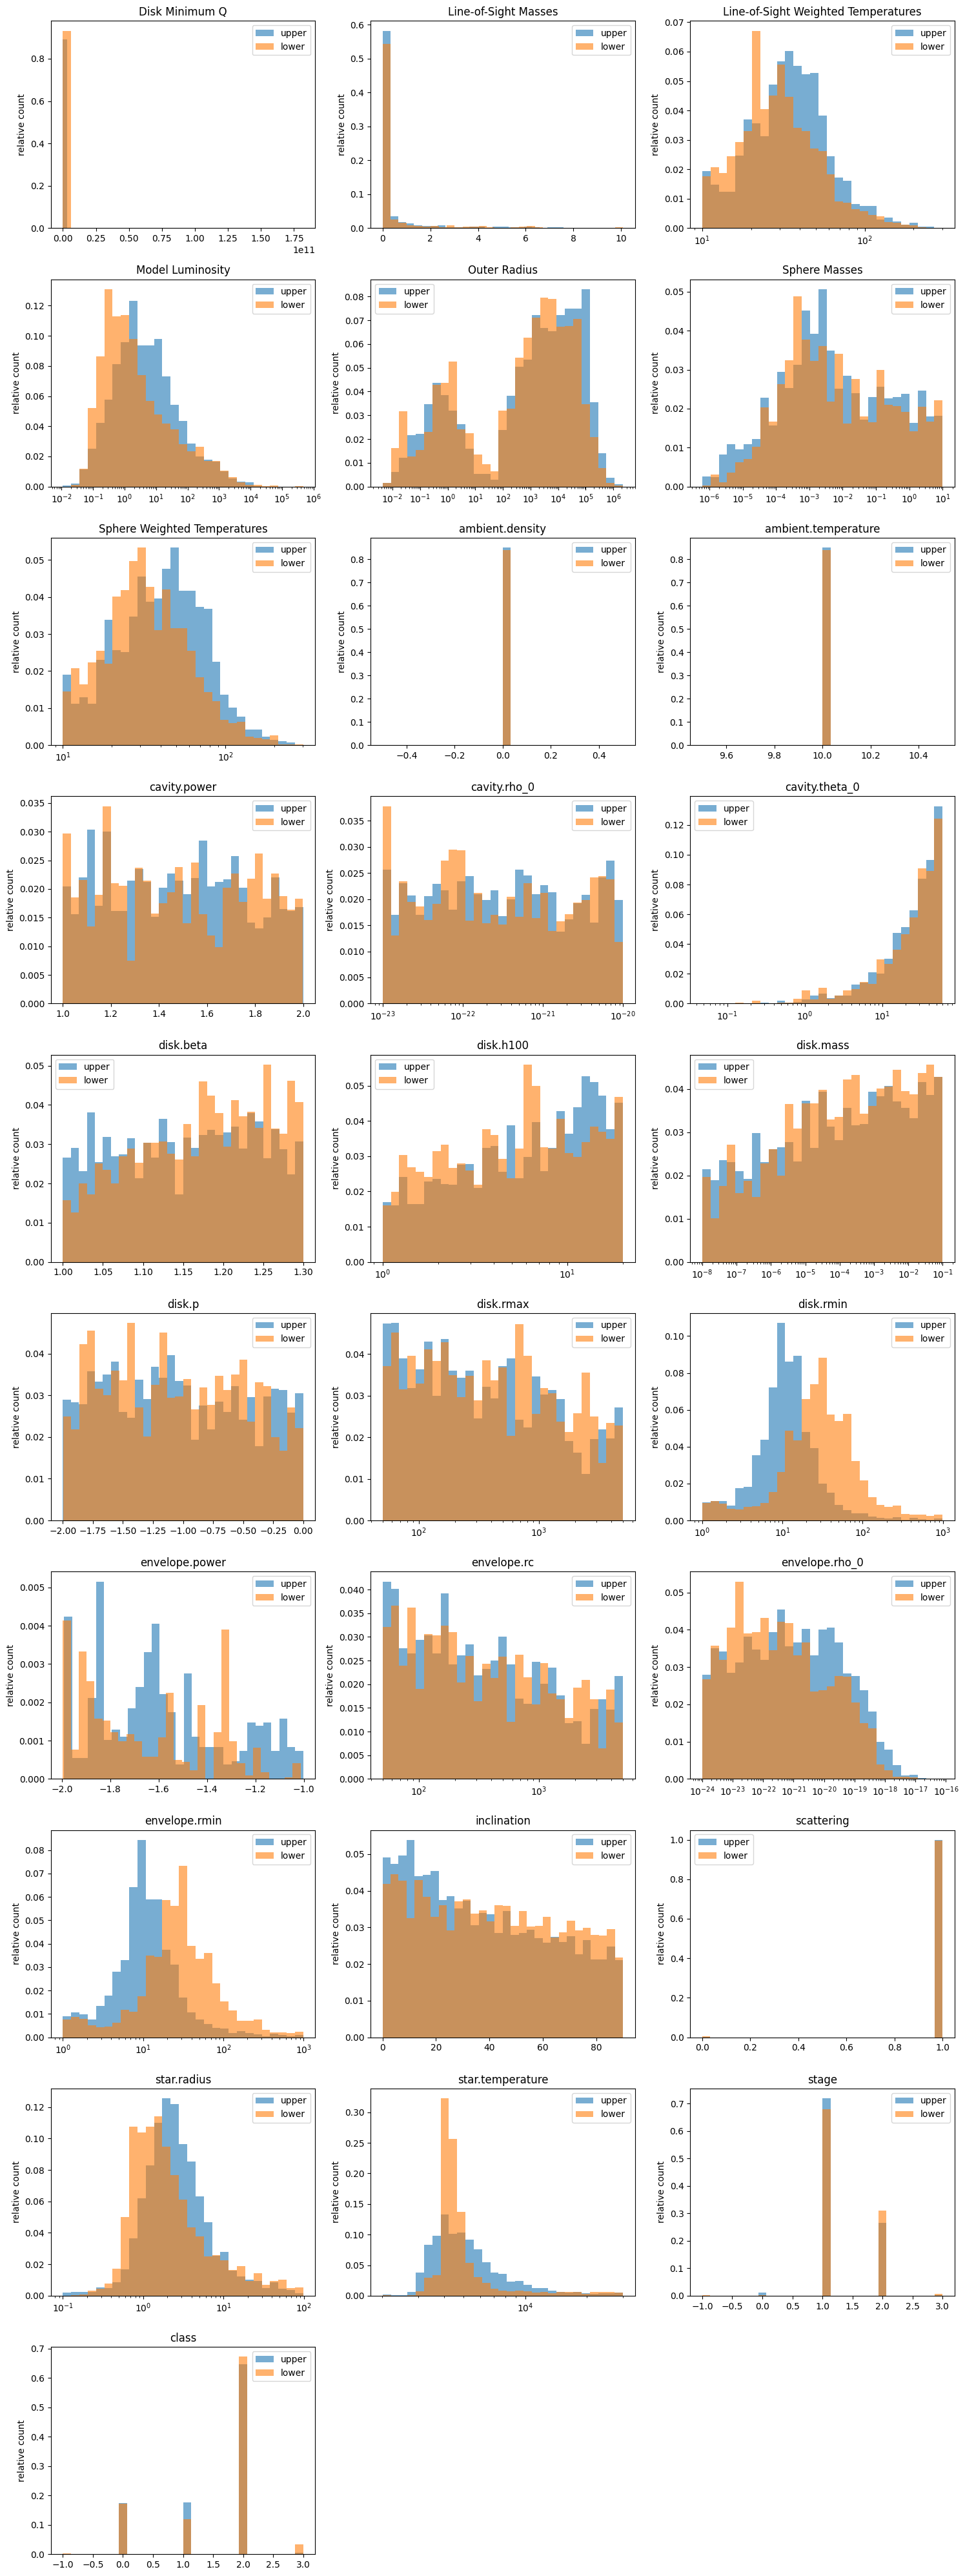

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

log_scales = ['disk.h100', 'Sphere Weighted Temperatures', 'Line-of-Sight Weighted Temperatures', 
'disk.rmax', 'envelope.rc', 'star.temperature']
# params_upper and params_lower (OrderedDict) should have been created in the previous cell
param_names = list(params_upper.keys())
if len(param_names) == 0:
    print('No parameters found in pars files')
else:
    nparams = len(param_names)
    ncols = 3
    nrows = int(np.ceil(nparams / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
    axes = np.array(axes).reshape(-1)

    def _select(arr, idx_arr):
        arr = np.atleast_1d(arr)
        idx_arr = np.asarray(idx_arr, dtype=int)
        if idx_arr.size == 0:
            return np.array([])
        idx_arr = idx_arr[idx_arr >= 0]
        idx_arr = idx_arr[idx_arr < arr.size]
        if idx_arr.size == 0:
            return np.array([])
        return arr[idx_arr]

    for i, p in enumerate(param_names):
        ax = axes[i]
        print(p)
        print(params_upper[p])
        #a_up = _select(params_upper[p], upper_temp_mask)
        #a_lo = _select(params_lower[p], lower_temp_mask)
        a_up = np.array(params_upper[p])
        a_lo = np.array(params_lower[p])
        # drop NaNs
        #a_up = a_up[~np.isnan(a_up)]
        #a_lo = a_lo[~np.isnan(a_lo)]
        if a_up.size == 0 and a_lo.size == 0:
            ax.text(0.5, 0.5, f'no data for {p}', ha='center')
            ax.set_title(p)
            continue
        all_vals = np.concatenate([a_up, a_lo]) if (a_up.size + a_lo.size) > 0 else np.array([])
        amin = np.nanmin(all_vals)
        amax = np.nanmax(all_vals)
        # choose log bins for large dynamic range of positive values
        use_log = (amin > 0) and ((amax / amin) > 100)
        if p in log_scales:
            use_log = True
        if use_log:
            bins = np.logspace(np.log10(max(amin,1e-30)), np.log10(amax), 30)
            ax.set_xscale('log')
        else:
            bins = 30
        #print length of a_up and a_lo
        print(f'Plotting {p}: upper={a_up.size}, lower={a_lo.size}')
        if a_up.size>0:
            ax.hist(a_up, bins=bins, alpha=0.6, label='upper', color='C0', weights=np.ones_like(a_up)/a_up.size)
        if a_lo.size>0:
            ax.hist(a_lo, bins=bins, alpha=0.6, label='lower', color='C1', weights=np.ones_like(a_lo)/a_lo.size)
        ax.set_title(p)
        ax.set_ylabel('relative count')
        ax.legend()

    for j in range(nparams, axes.size):
        axes[j].axis('off')

    plt.tight_layout()



In [ ]:
import os
os.environ["CRDS_PATH"] = os.path.expanduser("~/crds_cache")
os.makedirs(os.environ["CRDS_PATH"], exist_ok=True)

os.environ["CRDS_SERVER_URL"] = "https://jwst-crds.stsci.edu"
os.environ["CRDS_CONTEXT"] = "jwst_1460.pmap"

from astropy.table import Table
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
from astroquery.svo_fps import SvoFps
from astropy.wcs import WCS
from astropy.io import fits
from dust_extinction.averages import RL85_MWGC, CT06_MWLoc
from dust_extinction.parameter_averages import CCM89




def get_mag(catalog, ww, filtername='f140m' ):
    print(ww.proj_plane_pixel_area())
    
    flux= (catalog['flux_fit_' + filtername] * u.MJy/u.sr * ww.proj_plane_pixel_area()).to(u.Jy)
    eflux_jy = (catalog['flux_err_' + filtername] * u.MJy/u.sr *  ww.proj_plane_pixel_area()).to(u.Jy)

    jfilts = SvoFps.get_filter_list('JWST')
    jfilts.add_index('filterID')
    wav = int(filtername[1:-1])

    zeropoint_ab = 3631 * u.Jy  # Default to AB magnitude zero point
 
    if wav < 500:

        zeropoint_vega = u.Quantity(jfilts.loc[f'JWST/NIRCam.{filtername.upper()}']['ZeroPoint'], u.Jy)
    else:
        zeropoint_vega = u.Quantity(jfilts.loc[f'JWST/MIRI.{filtername.upper()}']['ZeroPoint'], u.Jy)
   
    abmag = -2.5 * np.log10(flux / zeropoint_ab) * u.mag
    abmag_err = 2.5 / np.log(10) * np.abs(eflux_jy / flux) * u.mag

    vegamag = -2.5 * np.log10(flux / zeropoint_vega) * u.mag
    vegamag_err = 2.5 / np.log(10) * np.abs(eflux_jy / flux) * u.mag

    return  vegamag, vegamag_err, abmag, abmag_err


image_filenames ={
    "f140m": "/orange/adamginsburg/jwst/w51/images/jw06151-o001_t001_nircam_clear-f140m-merged_i2d.fits",
    "f162m": "/orange/adamginsburg/jwst/w51/images/jw06151-o001_t001_nircam_clear-f162m-merged_i2d.fits",
    "f182m": "/orange/adamginsburg/jwst/w51/images/jw06151-o001_t001_nircam_clear-f182m-merged_i2d.fits",
    "f187n": "/orange/adamginsburg/jwst/w51/images/jw06151-o001_t001_nircam_clear-f187n-merged_i2d.fits",
    "f210m": "/orange/adamginsburg/jwst/w51/images/jw06151-o001_t001_nircam_clear-f210m-merged_i2d.fits",
    "f335m": "/orange/adamginsburg/jwst/w51/images/jw06151-o001_t001_nircam_clear-f335m-merged_i2d.fits",
    "f360m": "/orange/adamginsburg/jwst/w51/images/jw06151-o001_t001_nircam_clear-f360m-merged_i2d.fits",
    "f405n": "/orange/adamginsburg/jwst/w51/images/jw06151-o001_t001_nircam_clear-f405n-merged_i2d.fits",
    "f410m": "/orange/adamginsburg/jwst/w51/images/jw06151-o001_t001_nircam_clear-f410m-merged_i2d.fits", # weird, the filename is different from what is downloaded with the STScI pipeline...
    "f480m": "/orange/adamginsburg/jwst/w51/images/jw06151-o001_t001_nircam_clear-f480m-merged_i2d.fits",
    "f560w": "/orange/adamginsburg/jwst/w51/F560W/pipeline/jw06151-o002_t001_miri_f560w_i2d.fits",
    "f770w": "/orange/adamginsburg/jwst/w51/F770W/pipeline/jw06151-o002_t001_miri_f770w_i2d.fits",
    "f1000w": "/orange/adamginsburg/jwst/w51/F1000W/pipeline/jw06151-o002_t001_miri_f1000w_i2d.fits",
    "f1280w": "/orange/adamginsburg/jwst/w51/F1280W/pipeline/jw06151-o002_t001_miri_f1280w_i2d.fits",
    "f2100w": "/orange/adamginsburg/jwst/w51/F2100W/pipeline/jw06151-o002_t001_miri_f2100w_i2d.fits",
    
}
catalog = Table.read('/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/final_catalog_new_cfit_cut.fits')
nmatch = catalog['nmatch_bands']
catalog = catalog[nmatch>3]
print(catalog.colnames)


f140m_header = fits.getheader(image_filenames['f140m'], ext=('SCI', 1))
f162m_header = fits.getheader(image_filenames['f162m'], ext=('SCI', 1))
f182m_header = fits.getheader(image_filenames['f182m'], ext=('SCI', 1))
f210m_header = fits.getheader(image_filenames['f210m'], ext=('SCI', 1))
f335m_header = fits.getheader(image_filenames['f335m'], ext=('SCI', 1))
f360m_header = fits.getheader(image_filenames['f360m'], ext=('SCI', 1))
f405n_header = fits.getheader(image_filenames['f405n'], ext=('SCI', 1))
f410m_header = fits.getheader(image_filenames['f410m'], ext=('SCI', 1))
f480m_header = fits.getheader(image_filenames['f480m'], ext=('SCI', 1))
f560w_header = fits.getheader(image_filenames['f560w'], ext=('SCI', 1))
f770w_header = fits.getheader(image_filenames['f770w'], ext=('SCI', 1))
f1000w_header = fits.getheader(image_filenames['f1000w'], ext=('SCI', 1))
f1280w_header = fits.getheader(image_filenames['f1280w'], ext=('SCI', 1))
f2100w_header = fits.getheader(image_filenames['f2100w'], ext=('SCI', 1))



f140m_mag = get_mag(catalog, WCS(f140m_header), filtername='f140m')
f162m_mag = get_mag(catalog, WCS(f162m_header), filtername='f162m')
f182m_mag = get_mag(catalog, WCS(f182m_header), filtername='f182m')
f210m_mag = get_mag(catalog, WCS(f210m_header), filtername='f210m')
f335m_mag = get_mag(catalog, WCS(f335m_header), filtername='f335m')
f360m_mag = get_mag(catalog, WCS(f360m_header), filtername='f360m')
f405n_mag = get_mag(catalog, WCS(f405n_header), filtername='f405n')
f410m_mag = get_mag(catalog, WCS(f410m_header), filtername='f410m')
f480m_mag = get_mag(catalog, WCS(f480m_header), filtername='f480m')
f560w_mag = get_mag(catalog, WCS(f560w_header), filtername='f560w')
f770w_mag = get_mag(catalog, WCS(f770w_header), filtername='f770w')
f1000w_mag = get_mag(catalog, WCS(f1000w_header), filtername='f1000w')
f1280w_mag = get_mag(catalog, WCS(f1280w_header), filtername='f1280w')
f2100w_mag = get_mag(catalog, WCS(f2100w_header), filtername='f2100w')

f187n_header = fits.getheader(image_filenames['f187n'], ext=('SCI', 1))
f187n_mag = get_mag(catalog, WCS(f187n_header), filtername='f187n')


num_sources = len(catalog)

from dust_extinction.averages import RL85_MWGC, CT06_MWGC
from dust_extinction.parameter_averages import CCM89
import astropy.constants as const

ext = CT06_MWLoc()
def plot_extvec_cmd(ax, color1, mag1, ext=CT06_MWGC(), extvec_scale=200, start=None,
                    color='y', head_width=0.5, color1_data=None, mag1_data=None, label=None, fontsize=15):
    def get_wave(c):
        if c == '410m405': return 4.10*u.um
        if c == '405m410': return 4.05*u.um
        if c == 'Hmag': return 1.634*u.um
        if c == 'Ksmag': return 2.143527*u.um
        return int(c[1:-1])/100*u.um

    w1 = get_wave(color1[0])
    w2 = get_wave(color1[1])
    w3 = get_wave(mag1[0])

    if w1 > w2:
        w1, w2 = w2, w1
        color1 = color1[::-1]
    print(w1,w2,w3)

    # Only plot if all are in valid range
    try:
        e_1 = ext(1/w1) * extvec_scale
        e_2 = ext(1/w2) * extvec_scale
        e_3 = ext(1/w3) * extvec_scale
    except ValueError as e:
        print(f"Extinction vector not plotted: {e}")
        return
    print(w1,w2,w3)
    print(e_1, e_2, e_3)
                "import matplotlib.pyplot as plt",
                "import numpy as np",
                "",
                "# params_upper and params_lower (OrderedDict) should have been created in the previous cell",
                "param_names = list(params_upper.keys())",
                "if len(param_names) == 0:",
                "    print('No parameters found in pars files')",
                "else:",
                "    nparams = len(param_names)",
                "    ncols = 3",
                "    nrows = int(np.ceil(nparams / ncols))",
                "    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))",
                "    axes = np.array(axes).reshape(-1)",
                "",
                "    def _select(arr, idx_arr):",
                "        idx_arr = np.asarray(idx_arr, dtype=int)",
                "        if idx_arr.size == 0:",
                "            return np.array([])",
                "        idx_arr = idx_arr[idx_arr < arr.size]",
                "        return arr[idx_arr]",
                "",
                "    for i, p in enumerate(param_names):",
                "        ax = axes[i]",
                "        a_up = _select(params_upper[p], color1_upper_idx_to_all_10)",
                "        a_lo = _select(params_lower[p], color1_lower_idx_to_all_10)",
                "        # drop NaNs",
                "        a_up = a_up[~np.isnan(a_up)]",
                "        a_lo = a_lo[~np.isnan(a_lo)]",
                "        if a_up.size == 0 and a_lo.size == 0:",
                "            ax.text(0.5, 0.5, f'no data for {p}', ha='center')",
                "            ax.set_title(p)",
                "            continue",
                "        all_vals = np.concatenate([a_up, a_lo]) if (a_up.size + a_lo.size) > 0 else np.array([])",
                "        amin = np.nanmin(all_vals)",
                "        amax = np.nanmax(all_vals)",
                "        # choose log bins for large dynamic range of positive values",
                "        use_log = (amin > 0) and ((amax / amin) > 100)",
                "        if use_log:",
                "            bins = np.logspace(np.log10(max(amin,1e-30)), np.log10(amax), 30)",
                "            ax.set_xscale('log')",
                "        else:",
                "            bins = 30",
                "        if a_up.size>0:",
                "            ax.hist(a_up, bins=bins, alpha=0.6, label='upper', color='C0')",
                "        if a_lo.size>0:",
                "            ax.hist(a_lo, bins=bins, alpha=0.6, label='lower', color='C1')",
                "        ax.set_title(p)",
                "        ax.set_ylabel('count')",
                "        ax.legend()",
                "",
                "    for j in range(nparams, axes.size):",
                "        axes[j].axis('off')",
                "",
                "    plt.tight_layout()",
                "",
                "# To save the figure automatically, uncomment and set `imgsavedir` above",
                "# fig.savefig(imgsavedir + 'params_histograms.png', dpi=150)",
}
filter_names = list(mags.keys())






IndentationError: unexpected indent (2038501.py, line 143)

In [ ]:
import matplotlib as mpl
from matplotlib.path import Path
from astropy.table import Table
import crds
parsec_av0 = Table.read('/home/t.yoo/parsec_av0.txt', format='ascii')
parsec_av0.pprint(max_width=-1, max_lines=-1)   
m_init = parsec_av0['col4']  
parsec_av0 = parsec_av0[m_init<300]              
logage_av0 = parsec_av0['col3']
mass_av0 = parsec_av0['col6']
print(np.min(m_init), np.max(m_init))
print(np.min(mass_av0), np.max(mass_av0))
F140Mmag_av0 = parsec_av0['col39'] + 5*np.log10(5400)-5
F162Mmag_av0 = parsec_av0['col40']+ 5*np.log10(5400)-5
F182Mmag_av0 = parsec_av0['col41']+ 5*np.log10(5400)-5
F210Mmag_av0 = parsec_av0['col42']+ 5*np.log10(5400)-5
F335Mmag_av0 = parsec_av0['col45']+ 5*np.log10(5400)-5
F360Mmag_av0 = parsec_av0['col46']+ 5*np.log10(5400)-5
F410Mmag_av0 = parsec_av0['col47']+ 5*np.log10(5400)-5
F480Mmag_av0 = parsec_av0['col50']+ 5*np.log10(5400)-5
age_idx = logage_av0 == 6
idx_01msun = np.argmin(np.abs(mass_av0[age_idx]-0.1))
idx_20msun = np.argmin(np.abs(mass_av0[age_idx]-20))
print(F162Mmag_av0)
print('age_idx:', age_idx, 'idx_01msun:', idx_01msun, 'idx_20msun:', idx_20msun)
isochrone_x_start = F162Mmag_av0[age_idx][idx_01msun] - F210Mmag_av0[age_idx][idx_01msun]
isochrone_x_end = F162Mmag_av0[age_idx][idx_20msun] - F210Mmag_av0[age_idx][idx_20msun]
isocrhone_y_start = F162Mmag_av0[age_idx][idx_01msun]
isocrhone_y_end = F162Mmag_av0[age_idx][idx_20msun]
color_slope = (isocrhone_y_end - isocrhone_y_start) / (isochrone_x_end - isochrone_x_start)
color_intercept = isocrhone_y_start - color_slope * isochrone_x_start

def get_av(color, mag, ext=CT06_MWLoc(), color1=('f140m', 'f162m'), mag1=('f140m',), isochrone_line_params=None):
    # Get the slope and intercept of the isochrone line
    m_iso, b_iso = isochrone_line_params
    print('color1:', color1, 'mag1:', mag1)

    # Get the extinction vector components
    w_color1_1 = int(color1[0][1:-1])/100*u.um
    w_color1_2 = int(color1[1][1:-1])/100*u.um
    w_mag1 = int(mag1[0][1:-1])/100*u.um
    print('w_color1_1:', w_color1_1, 'w_color1_2:', w_color1_2, 'w_mag1:', w_mag1)

    e_color1_1 = ext(1/w_color1_1)
    e_color1_2 = ext(1/w_color1_2)
    e_mag1 = ext(1/w_mag1)

    # get the contact to the isochrone line along the extinction vector
    # the extinction vector can be represented as a line with slope m_ext = e_mag1 / (e_color1_1 - e_color1_2) and passing through the point (color, mag)
    m_ext = e_mag1 / (e_color1_1 - e_color1_2)
    b_ext = mag - m_ext * color

    # find the intersection of the isochrone line and the extinction vector
    x_int = (b_ext - b_iso) / (m_iso - m_ext)
    y_int = m_iso * x_int + b_iso

    # calculate A_V as the distance from (color, mag) to (x_int, y_int) along the extinction vector
    av = (mag - y_int) / ext(1/w_mag1)
    av[av < 0] = 0
    return av
parsec_mags = {
    'f140m': F140Mmag_av0,
    'f162m': F162Mmag_av0,
    'f182m': F182Mmag_av0,
    'f210m': F210Mmag_av0,
    'f335m': F335Mmag_av0,
    'f360m': F360Mmag_av0,
    'f410m': F410Mmag_av0,
    'f480m': F480Mmag_av0,
}

f162 = f162m_mag[0].to_value(u.mag)
f210 = f210m_mag[0].to_value(u.mag)
f360 = f360m_mag[0].to_value(u.mag)
f480 = f480m_mag[0].to_value(u.mag)
isochrone_x_start = parsec_mags['f162m'][age_idx][idx_01msun] - parsec_mags['f210m'][age_idx][idx_01msun]
isochrone_x_end = parsec_mags['f162m'][age_idx][idx_20msun] - parsec_mags['f210m'][age_idx][idx_20msun]
isochrone_y_start = parsec_mags['f162m'][age_idx][idx_01msun]
isochrone_y_end = parsec_mags['f162m'][age_idx][idx_20msun]

color_slope = (isochrone_y_end - isochrone_y_start) / (isochrone_x_end - isochrone_x_start)
color_intercept = isochrone_y_start - color_slope * isochrone_x_start
av_estimate = get_av(f162 - f210, f162, ext=CT06_MWLoc(), color1=('f162m', 'f210m'), mag1=('f162m',), isochrone_line_params=(color_slope, color_intercept))

line_slope = (27 - 7) / (1.3 - 0.4)
line_intercept = 7 - line_slope * 0.4


upper_idx = np.where((f360-f480 > 0.15 + (1.5/6)*(f162-f210)) & (f162 - (line_slope * (f162 - f210) + line_intercept) < 0))[0]
lower_idx = np.where((f360-f480 <= 0.15 + (1.5/6)*(f162-f210)) & (f162 - (line_slope * (f162 - f210) + line_intercept) < 0))[0]
print(len(catalog))
print(len(f360), len(f480), len(f162), len(f210))
print(len(upper_idx), len(lower_idx))


 col1    col2  col3      col4          col5       col6   col7   col8   col9  col10 col11 col12   col13  col14  col15  col16  col17  col18   col19   col20   col21   col22    col23     col24     col25   col26   col27   col28   col29   col30   col31   col32   col33   col34   col35   col36   col37   col38   col39   col40   col41   col42   col43   col44   col45   col46   col47   col48   col49   col50 
------ ------- ---- -------------- ------------ ------- ------ ------ ------ ----- ----- ------ ------- ------ ------ ------ ------ ----- --------- ----- --------- ------ --------- --------- --------- ------ ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- ------- -------
0.0207 0.15867  5.0   0.0908484459 1.0897678296   0.091  -0.78 3.4382  2.881     0   0.0  0.545     0.0    0.0    0.0    0.0    0.0    -1 -2.54e-13   0.0    0.6936 0.2855  0.003749  0.001011  0.009172

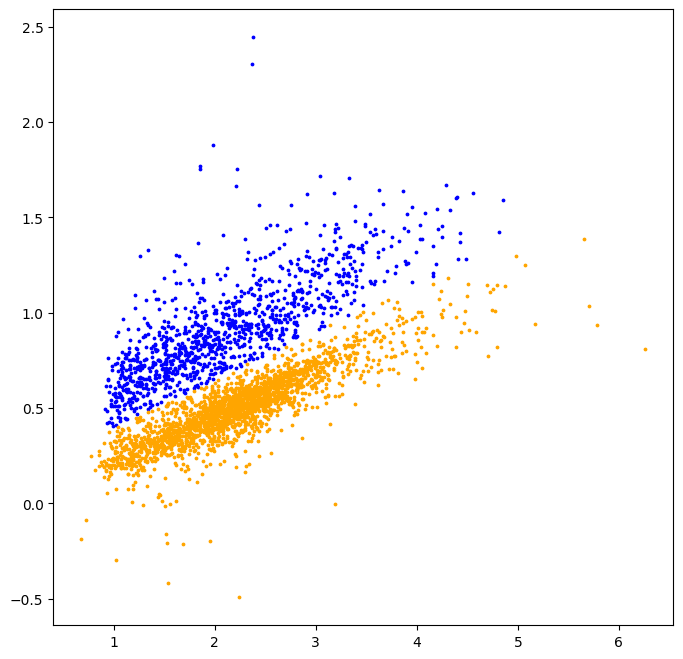

In [ ]:
fig = plt.figure(figsize=(8,8))
ax1 = fig.add_subplot(111)
ax1.scatter(f162[all_idx_upper] - f210[all_idx_upper], f360[all_idx_upper]-f480[all_idx_upper], s=3, color='blue', label='Upper')
ax1.scatter(f162[all_idx_lower] - f210[all_idx_lower], f360[all_idx_lower]-f480[all_idx_lower], s=3, color='orange', label='Lower')

In [ ]:
color1_idx = np.where((f162-f210>1) & (f162-f210<2))[0]

color1_upper_idx = np.intersect1d(color1_idx, all_idx_upper)
color1_lower_idx = np.intersect1d(color1_idx, all_idx_lower)

color1_upper_idx_to_all = np.where(np.isin(all_idx_upper, color1_upper_idx))[0]
color1_lower_idx_to_all = np.where(np.isin(all_idx_lower, color1_lower_idx))[0]
color1_upper_idx_to_all_10 = []
for idx in color1_upper_idx_to_all:
    color1_upper_idx_to_all_10.extend(np.arange(idx*10, idx*10+10).tolist())
color1_lower_idx_to_all_10 = []
for idx in color1_lower_idx_to_all:
    color1_lower_idx_to_all_10.extend(np.arange(idx*10, idx*10+10).tolist())
print('color1_upper_idx_to_all_10:', color1_upper_idx_to_all_10)

color1_upper_idx_to_all_10: [10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221, 222, 223, 224, 225, 226, 227, 228, 229, 230, 231, 232, 233, 234, 235, 236, 237, 238, 239, 2

[0.00538861 0.43417295 0.03581044 ... 0.06059985        nan 0.02322779]


Text(0.5, 1.0, 'Cavity Density Distribution')

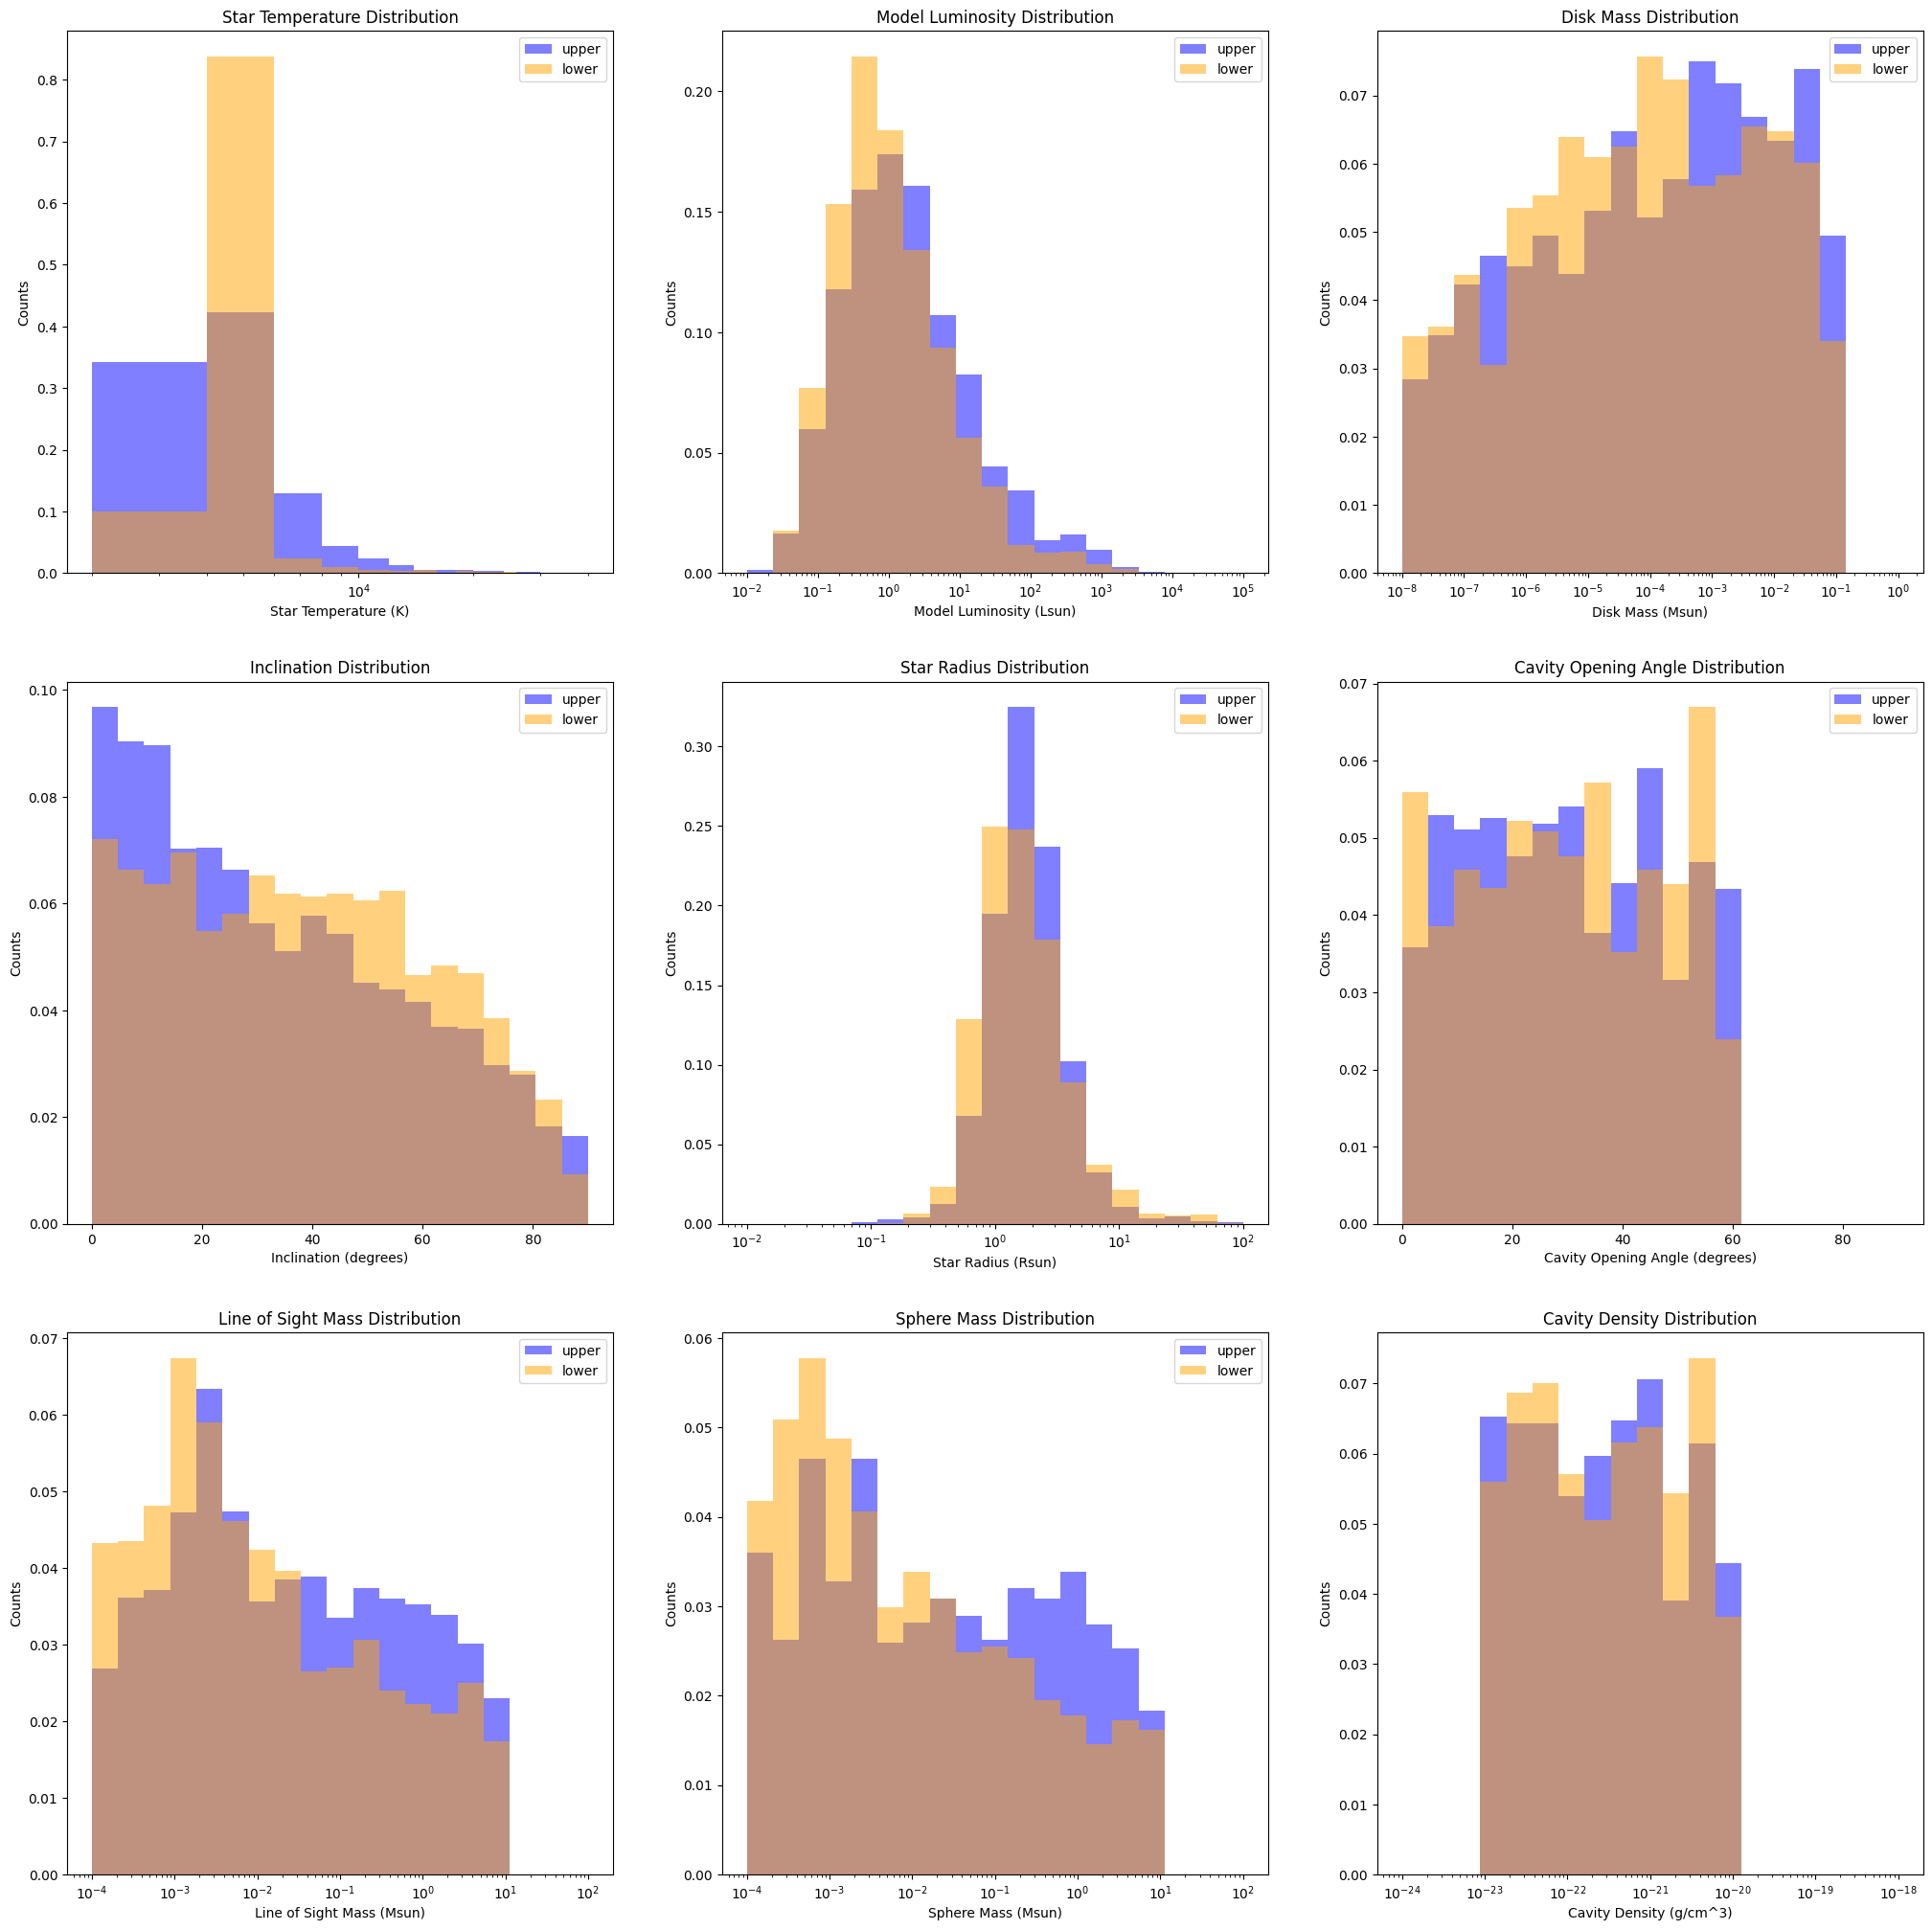

In [ ]:
star_temperatures_upper = np.asarray(star_temperatures_upper, dtype=float)
star_temperatures_lower = np.asarray(star_temperatures_lower, dtype=float)
star_luminosities_upper = np.asarray(star_luminosities_upper, dtype=float)
star_luminosities_lower = np.asarray(star_luminosities_lower, dtype=float)
disk_masses_upper = np.asarray(disk_masses_upper, dtype=float)
disk_masses_lower = np.asarray(disk_masses_lower, dtype=float)
inclinations_upper = np.asarray(inclinations_upper, dtype=float)
inclinations_lower = np.asarray(inclinations_lower, dtype=float)
star_radius_upper = np.asarray(star_radius_upper, dtype=float)
star_radius_lower = np.asarray(star_radius_lower, dtype=float)
cavity_theta_0_upper = np.asarray(cavity_theta_0_upper, dtype=float)
cavity_theta_0_lower = np.asarray(cavity_theta_0_lower, dtype=float)
line_of_sight_masses_upper = np.asarray(line_of_sight_masses_upper, dtype=float)
line_of_sight_masses_lower = np.asarray(line_of_sight_masses_lower, dtype=float)
sphere_masses_upper = np.asarray(sphere_masses_upper, dtype=float)
sphere_masses_lower = np.asarray(sphere_masses_lower, dtype=float)
cavity_rho_0_upper = np.asarray(cavity_rho_0_upper, dtype=float)
cavity_rho_0_lower = np.asarray(cavity_rho_0_lower, dtype=float)
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict
from tqdm.auto import tqdm
all_gs = glob.glob('/blue/adamginsburg/richardson.t/research/flux/r+24_models-1.2/s*')
all_gs = [g.split('/')[-1] for g in all_gs if 'ipynb' not in g]
# Cache pars tables to avoid re-reading many times
pars_cache = {}
all_gs = 
for g in all_gs:
    geo = g.split('/')[-1]
    try:
        pars_cache[geo] = Table.read(f'/blue/adamginsburg/richardson.t/research/flux/pars/{geo}_augmented.fits')
    except Exception:
        pars_cache[geo] = None

# Collect union of parameter names (exclude MODEL_NAME)
param_names = set()
for geo, pars in pars_cache.items():
    if pars is None:
        continue
    for col in pars.colnames:
        if col == 'MODEL_NAME':
            continue
        param_names.add(col)
param_names = sorted(param_names)

# Build per-parameter lists for upper and lower selections
params_upper = {p: [] for p in param_names}
params_lower = {p: [] for p in param_names}

def _get_val(pars, p, idx):
    if pars is None or p not in pars.colnames:
        return np.nan
    try:
        v = pars[p][idx].item()
        # strip units if present
        if hasattr(v, 'value'):
            return float(v.value)
        return float(v)
    except Exception:
        return np.nan

for geo, model_name in zip(all_geo_upper, all_model_names_upper):
    pars = pars_cache.get(geo)
    if pars is None:
        for p in param_names:
            params_upper[p].append(np.nan)
        continue
    try:
        match_idx = np.where(pars['MODEL_NAME'] == model_name)[0]
        if match_idx.size == 0:
            for p in param_names:
                params_upper[p].append(np.nan)
            continue
        mi = match_idx[0]
    except Exception:
        mi = None
    for p in param_names:
        if mi is None:
            params_upper[p].append(np.nan)
        else:
            params_upper[p].append(_get_val(pars, p, mi))

for geo, model_name in zip(all_geo_lower, all_model_names_lower):
    pars = pars_cache.get(geo)
    if pars is None:
        for p in param_names:
            params_lower[p].append(np.nan)
        continue
    try:
        match_idx = np.where(pars['MODEL_NAME'] == model_name)[0]
        if match_idx.size == 0:
            for p in param_names:
                params_lower[p].append(np.nan)
            continue
        mi = match_idx[0]
    except Exception:
        mi = None
    for p in param_names:
        if mi is None:
            params_lower[p].append(np.nan)
        else:
            params_lower[p].append(_get_val(pars, p, mi))

# Convert to arrays
for p in param_names:
    params_upper[p] = np.asarray(params_upper[p], dtype=float)
    params_lower[p] = np.asarray(params_lower[p], dtype=float)

# Now plot all parameters in a grid
nparams = len(param_names)
ncols = 3
nrows = int(np.ceil(nparams / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
axes = np.array(axes).reshape(-1)

def _select(arr, idx_arr):
    idx_arr = np.asarray(idx_arr, dtype=int)
    if idx_arr.size == 0:
        return np.array([])
    # guard for out-of-bounds
    idx_arr = idx_arr[idx_arr < arr.size]
    return arr[idx_arr]

for i, p in enumerate(param_names):
    ax = axes[i]
    a_up = _select(params_upper[p], color1_upper_idx_to_all_10)
    a_lo = _select(params_lower[p], color1_lower_idx_to_all_10)
    # drop NaN
    a_up = a_up[~np.isnan(a_up)]
    a_lo = a_lo[~np.isnan(a_lo)]
    # choose binning: log if all positive and dynamic range > 100
    all_vals = np.concatenate([a_up, a_lo]) if (a_up.size + a_lo.size) > 0 else np.array([])
    if all_vals.size == 0:
        ax.text(0.5, 0.5, f'no data for {p}', ha='center')
        ax.set_title(p)
        continue
    amin = np.nanmin(all_vals)
    amax = np.nanmax(all_vals)
    if amin > 0 and (amax / amin) > 100:
        bins = np.logspace(np.log10(max(amin,1e-30)), np.log10(amax), 30)
        ax.set_xscale('log')
    else:
        bins = 30
    if a_up.size>0:
        ax.hist(a_up, bins=bins, alpha=0.5, label='upper', color='blue', density=False)
    if a_lo.size>0:
        ax.hist(a_lo, bins=bins, alpha=0.5, label='lower', color='orange', density=False)
    ax.set_title(p)
    ax.legend()

# hide any unused axes
for j in range(nparams, axes.size):
    axes[j].axis('off')

plt.tight_layout()